***"Análisis Integral de Negocio: Optimización de Métricas Financieras y de Usuario". Distribuidora de entradas de eventos Showz***
======================================================
**Introducción**
Proyecto integral de análisis de negocio donde apliqué técnicas avanzadas de análisis de cohortes, economía unitaria y optimización de embudos de conversión para evaluar la salud financiera y operativa de una compañía relacionada en el mercado de distribución de entradas a eventos de entretenimiento.

Dentro del dataset se cuenta con datos de la empresa relacionados a:
- Registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018.
- Un archivo con los pedidos en este periodo.
- Estadísticas de gastos de marketing.

Lo que se pretende determinar en este proyecto es: 
- ¿Cómo los clientes usan el servicio?
- ¿cuándo empiezan a comprar?
- ¿cuánto dinero aporta cada cliente a la compañía?
- ¿cuándo los ingresos cubren el costo de adquisición de los clientes?

# Paso 1. Acceso y preparación de los datos para su posterior análisis

## Importación de librerías y paquetes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

## Acceso a los datos

In [2]:
visits = pd.read_csv('datasets/visits_log_us.csv')
orders = pd.read_csv('datasets/orders_log_us.csv')
costs = pd.read_csv('datasets/costs_us.csv')

## Análisis preliminar de dataframes

In [3]:
print(visits.info())
print("")
print(orders.info())
print("")
print(costs.info())
print("")
print(visits.head())
print("")
print(orders.head())
print("")
print(costs.head())
print("")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     -------------

## Optimización de datos

In [4]:
# Definición de función para reemplazo de espacios por _ en nombres de columnas
def change_spaces_column_names(dataframe):
    for column in dataframe.columns:
        new_column_name = column.replace(' ', '_')
        dataframe.rename(columns={column: new_column_name}, inplace=True)
    return dataframe

# Ejecución de función anterior para reemplazo de espacios por _
visits = change_spaces_column_names(visits)
orders = change_spaces_column_names(orders)
costs = change_spaces_column_names(costs)

# Cambio de datos de fechas de tipo object a datetime
visits['End_Ts'] = pd.to_datetime(visits['End_Ts'])
visits['Start_Ts'] = pd.to_datetime(visits['Start_Ts'])
orders['Buy_Ts'] = pd.to_datetime(orders['Buy_Ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# Paso 2. Generación de informes y cálculo de métricas

## 1. Visitas

### ¿Cuántas personas usan la plataforma de Showz cada día, semana y mes?

#### Análisis general de número de visitas a plataforma por día, semana y mes

=== UNIQUE USERS RESUME ===
Dairy average: 906 users
Weekly average: 5760 users
Monthly average: 23228 users


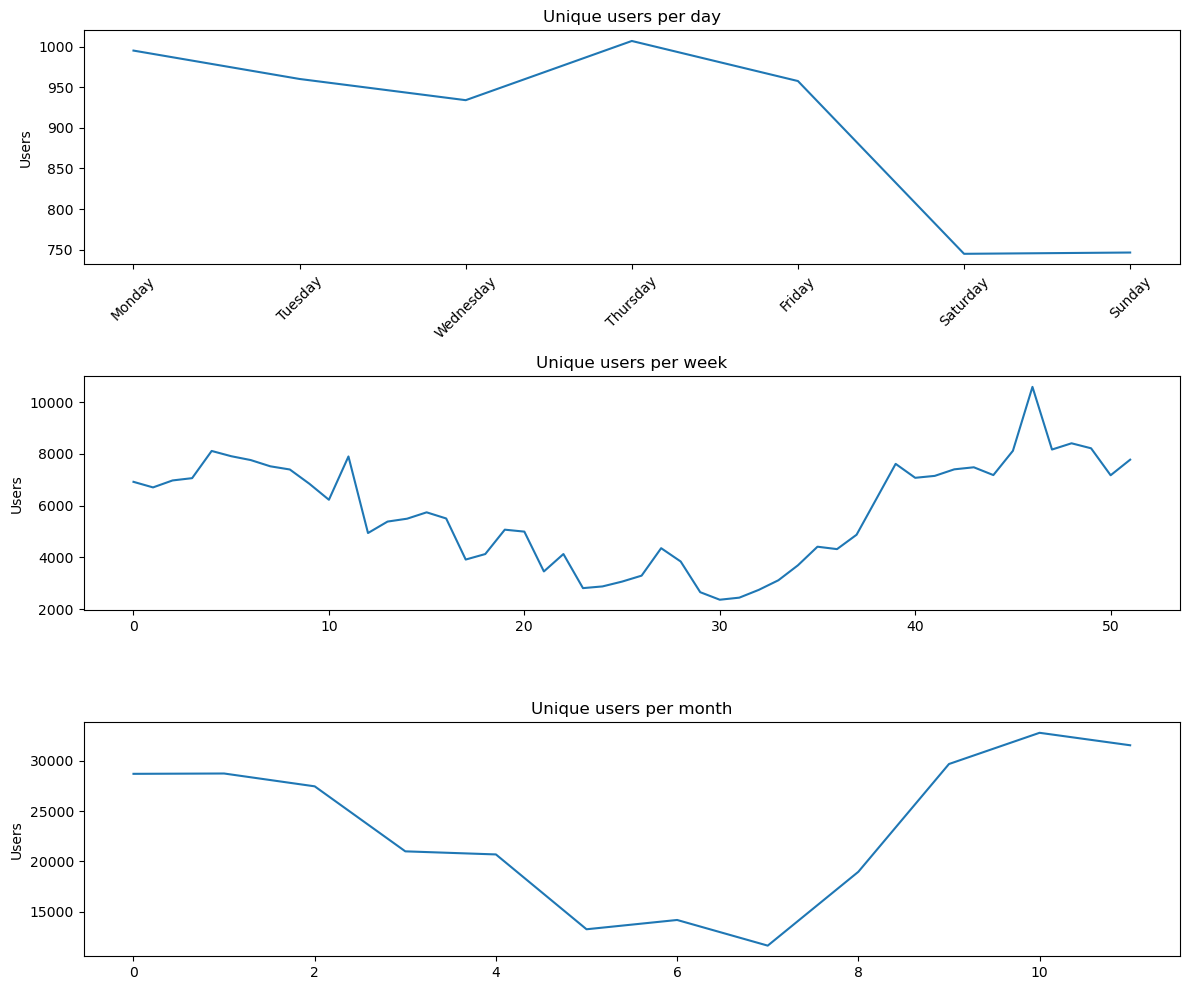

In [5]:
# Definición de día, semana y mes por cada visita realizada
visits['year'] = visits['Start_Ts'].dt.year
visits['month'] = visits['Start_Ts'].dt.month
visits['week'] = visits['Start_Ts'].dt.isocalendar().week
visits['dow'] = visits['Start_Ts'].dt.dayofweek

# Función para generación de df de conteo de usuarios por día, semana y mes 
# Para cada métrica, primero se agrupa por:
# - año 
# - (mes,semana,día) 
# luego se saca promedio en una agrupación por solo (mes,semana,día)
def users_by_month_df(visits_df):
    users_by_year_month = visits_df.groupby(['year','month']).agg({'Uid':'nunique'}).reset_index()
    mean_users_by_month = users_by_year_month.groupby('month').agg({'Uid':'mean'}).reset_index()
    return(mean_users_by_month)
def users_by_week_df(visits_df):
    users_by_year_week = visits_df.groupby(['year','week']).agg({'Uid':'nunique'}).reset_index()
    mean_users_by_week = users_by_year_week.groupby('week').agg({'Uid':'mean'}).reset_index()
    return(mean_users_by_week)
def users_by_dow_df(visits_df):
    users_by_year_week_dow = visits_df.groupby(['year','week','dow']).agg({'Uid':'nunique'}).reset_index()
    mean_users_by_week_dow = users_by_year_week_dow.groupby(['week','dow']).agg({'Uid':'mean'}).reset_index()
    mean_users_by_dow = mean_users_by_week_dow.groupby('dow').agg({'Uid':'mean'}).reset_index()
    all_days = pd.DataFrame({'dow': range(7)})
    mean_users_by_dow = all_days.merge(mean_users_by_dow, on='dow', how='left')
    mean_users_by_dow['Uid'] = mean_users_by_dow['Uid'].fillna(0)
    return mean_users_by_dow

# Generación de df 
mean_users_by_month = users_by_month_df(visits)
mean_users_by_week = users_by_week_df(visits)
mean_users_by_dow = users_by_dow_df(visits)

# Mostrar resumen de usuarios únicos
print("=== UNIQUE USERS RESUME ===")
print(f"Dairy average: {mean_users_by_dow['Uid'].mean():.0f} users")
print(f"Weekly average: {mean_users_by_week['Uid'].mean():.0f} users") 
print(f"Monthly average: {mean_users_by_month['Uid'].mean():.0f} users")

#Definición de gráficos para el reporte
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
# Gráfico diario
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
mean_users_by_dow['Uid'].plot(ax=axes[0], title='Unique users per day')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(days, rotation=45)
axes[0].set_ylabel('Users')
# Gráfico semanal  
mean_users_by_week['Uid'].plot(ax=axes[1], title='Unique users per week')
axes[1].set_ylabel('Users')
# Gráfico mensual
mean_users_by_month['Uid'].plot(ax=axes[2], title='Unique users per month')
axes[2].set_ylabel('Users')

#Impresión de gráficos
plt.tight_layout()
plt.show()

#### Análisis comparativo entre fuentes de anuncios del número de visitas a plataforma por día, semana y mes

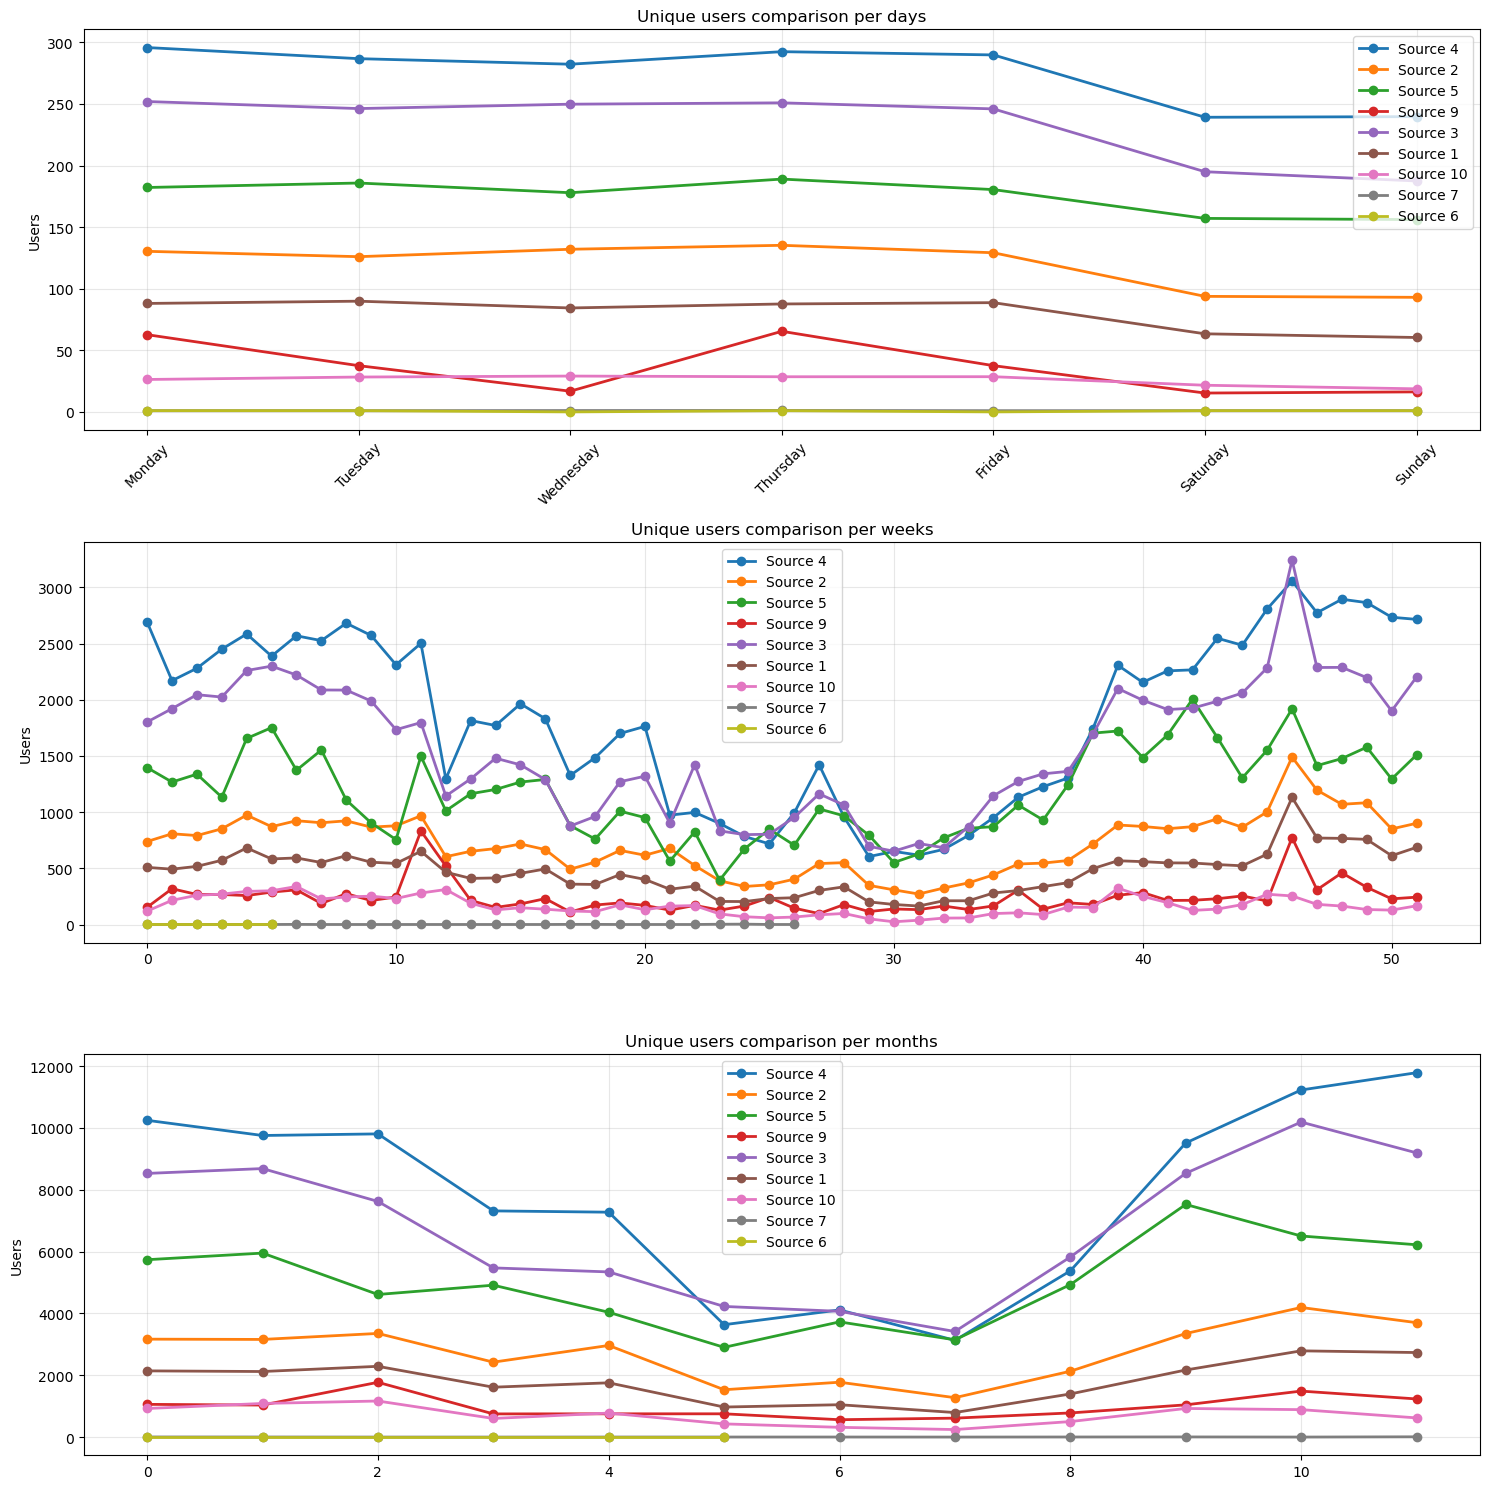

In [6]:
#Obtención de diferencia, en segundos, de la hora de inicio y fin de las visitas
visits['visit_length_s'] = (visits['End_Ts']-visits['Start_Ts']).dt.total_seconds()

# Función para generación de slices por cada fuente de anuncios
def create_slices_by_source(dataframe, column_name='Source_Id'):
   
    """
    Genera slices del dataframe por cada valor único de la columna especificada
    
    Args:
        dataframe: DataFrame a dividir
        column_name: Nombre de la columna para crear los slices
    
    Returns:
        dict: Diccionario donde las keys son los valores únicos y los values son los DataFrames
    """

    slices_dict = {}
    unique_values = dataframe[column_name].unique()
    
    for value in unique_values:
        slice_name = f"source_{value}"
        slices_dict[slice_name] = dataframe[dataframe[column_name] == value]
    
    return slices_dict

# Función para aplicación de funciones users_by_month_df, users_by_week_df y users_by_dow_df en una sola
def generate_all_user_dataframes(df):
    """
    Aplica las tres funciones de análisis de usuarios y devuelve los 3 DataFrames
    
    Args:
        df: DataFrame a analizar
    
    Returns:
        tuple: (df_monthly, df_weekly, df_daily) - Los tres DataFrames por separado
         """
    df_monthly = users_by_month_df(df)
    df_weekly = users_by_week_df(df)
    df_daily = users_by_dow_df(df)
    
    return df_daily, df_weekly, df_monthly

# Función para generar gráficos diarios, semanales y mensuales
def create_comparative_graphs(visits_slices):
    """
    Crea gráficos comparativos entre todas las fuentes de anuncios
    """
    # Preparar datos para comparación
    daily_data = {}
    weekly_data = {}
    monthly_data = {}
    
    # Obtener datos de todas las fuentes disponibles
    for source_key in visits_slices.keys():
        source_num = source_key.split('_')[1]
        daily, weekly, monthly = generate_all_user_dataframes(visits_slices[source_key])
        
        daily_data[f'Source {source_num}'] = daily['Uid'].values
        weekly_data[f'Source {source_num}'] = weekly['Uid'].values
        monthly_data[f'Source {source_num}'] = monthly['Uid'].values
    
    # Crear gráficos comparativos
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    
    # Gráfico diario comparativo
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for source_name, data in daily_data.items():
        axes[0].plot(range(7), data, marker='o', label=source_name, linewidth=2)
    axes[0].set_title('Unique users comparison per days')
    axes[0].set_xticks(range(7))
    axes[0].set_xticklabels(days, rotation=45)
    axes[0].set_ylabel('Users')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Gráfico semanal comparativo
    for source_name, data in weekly_data.items():
        axes[1].plot(range(len(data)), data, marker='o', label=source_name, linewidth=2)
    axes[1].set_title('Unique users comparison per weeks')
    axes[1].set_ylabel('Users')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Gráfico mensual comparativo
    for source_name, data in monthly_data.items():
        axes[2].plot(range(len(data)), data, marker='o', label=source_name, linewidth=2)
    axes[2].set_title('Unique users comparison per months')
    axes[2].set_ylabel('Users')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
# Uso de las funciones
visits_slices = create_slices_by_source(visits)
create_comparative_graphs(visits_slices)

#### Análisis comparativo entre dispositivos del número de visitas a plataforma por día, semana y mes

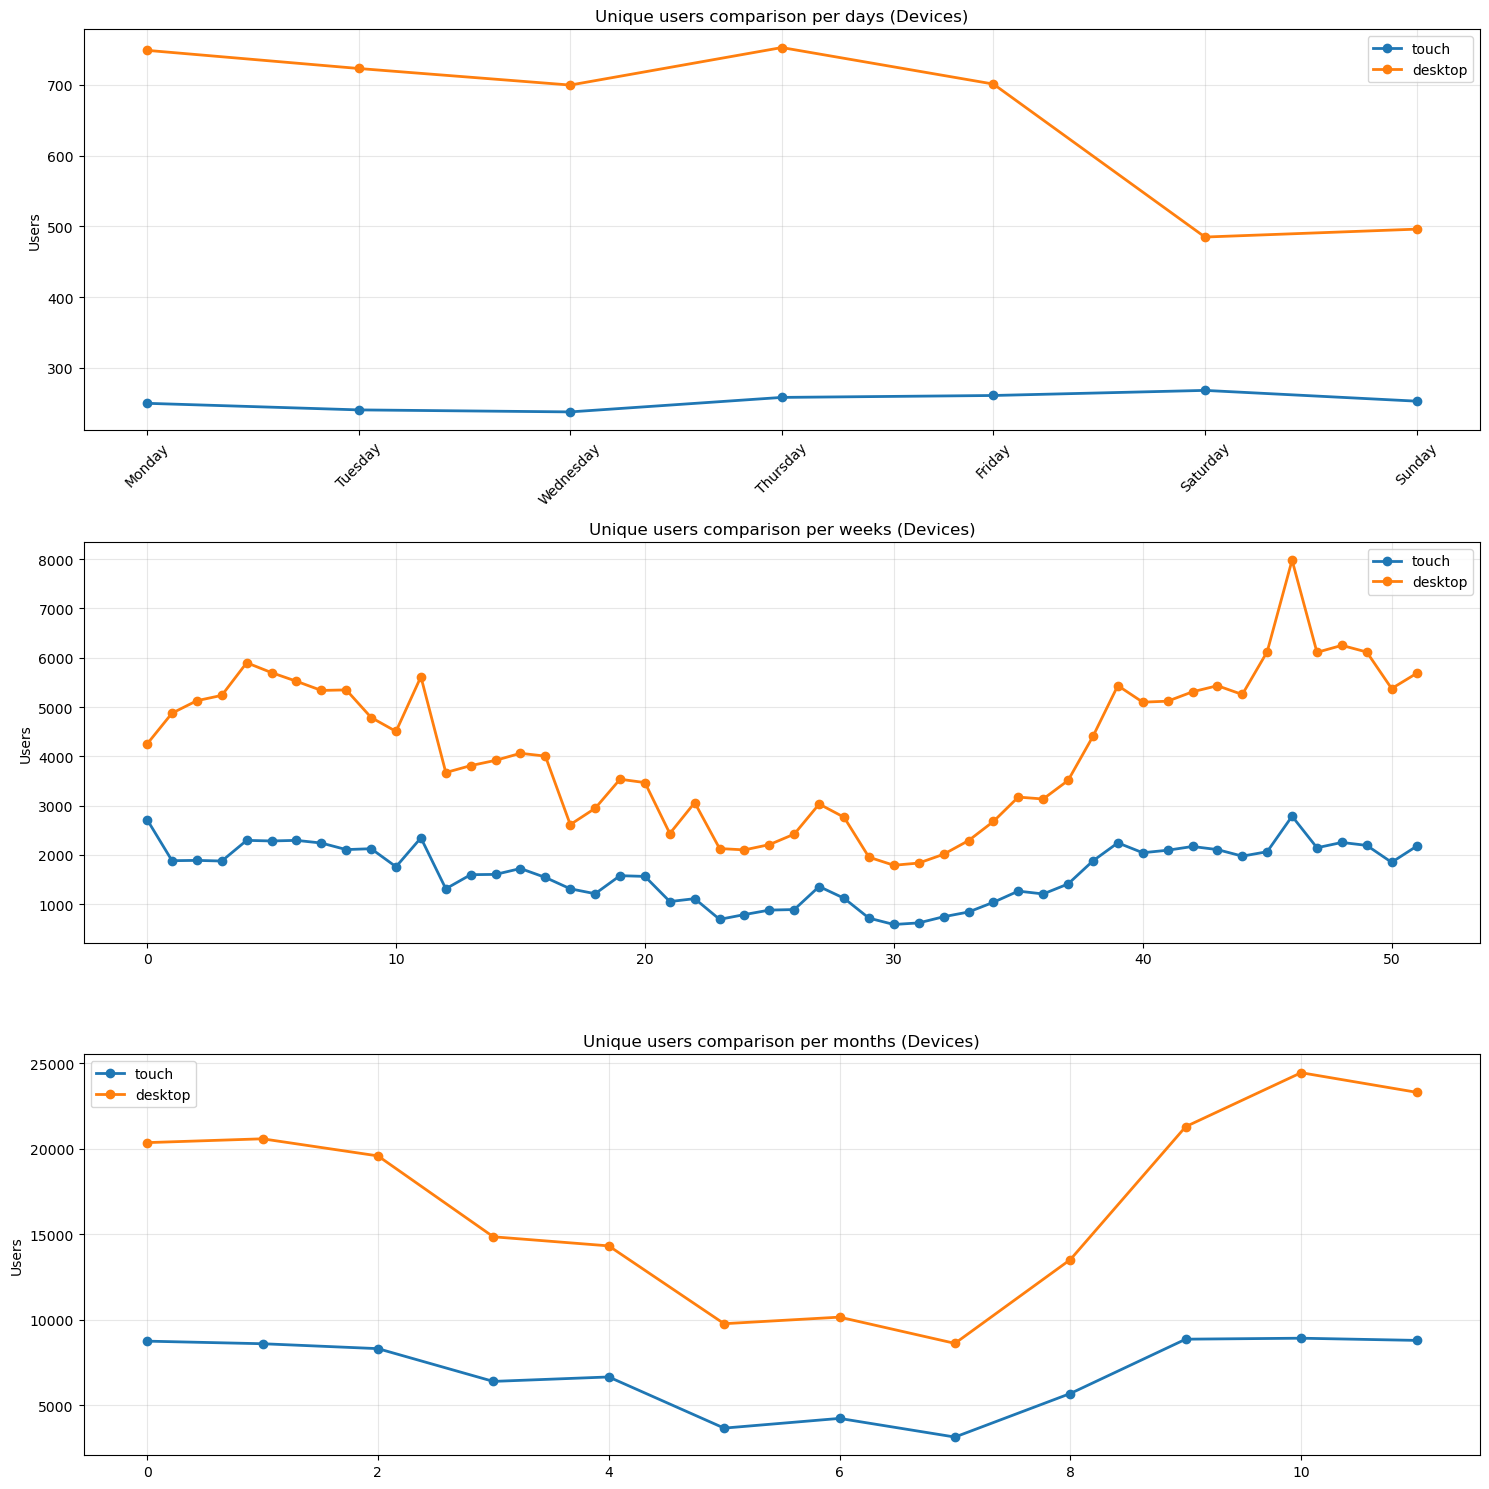

In [7]:
#Función para hacer slices por devices
def create_slices_by_device(dataframe, column_name='Device'):
    """
    Genera slices del dataframe por cada valor único de la columna Device
    Args:
        dataframe: DataFrame a dividir
        column_name: Nombre de la columna para crear los slices
    Returns:
        dict: Diccionario donde las keys son los nombres de dispositivos y los values son los DataFrames
    """
    slices_dict = {}
    unique_values = dataframe[column_name].unique()
    
    for value in unique_values:
        # Usar el nombre del dispositivo directamente como key
        slices_dict[value] = dataframe[dataframe[column_name] == value]
    
    return slices_dict

# Función para generar gráficos diarios, semanales y mensuales
def create_comparative_graphs_by_device(visits_device_slices):
    """
    Crea gráficos comparativos entre todos los tipos de dispositivos
    """
    # Preparar datos para comparación
    daily_data = {}
    weekly_data = {}
    monthly_data = {}
    
    # Obtener datos de todos los dispositivos disponibles
    for device_name, device_data in visits_device_slices.items():
        daily, weekly, monthly = generate_all_user_dataframes(device_data)
        
        daily_data[device_name] = daily['Uid'].values
        weekly_data[device_name] = weekly['Uid'].values
        monthly_data[device_name] = monthly['Uid'].values
    
    # Crear gráficos comparativos
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    
    # Gráfico diario comparativo
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for device_name, data in daily_data.items():
        axes[0].plot(range(7), data, marker='o', label=device_name, linewidth=2)
    
    axes[0].set_title('Unique users comparison per days (Devices)')
    axes[0].set_xticks(range(7))
    axes[0].set_xticklabels(days, rotation=45)
    axes[0].set_ylabel('Users')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Gráfico semanal comparativo
    for device_name, data in weekly_data.items():
        axes[1].plot(range(len(data)), data, marker='o', label=device_name, linewidth=2)
    
    axes[1].set_title('Unique users comparison per weeks (Devices)')
    axes[1].set_ylabel('Users')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Gráfico mensual comparativo
    for device_name, data in monthly_data.items():
        axes[2].plot(range(len(data)), data, marker='o', label=device_name, linewidth=2)
    
    axes[2].set_title('Unique users comparison per months (Devices)')
    axes[2].set_ylabel('Users')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Uso de las funciones
visits_slices_per_devices = create_slices_by_device(visits)
create_comparative_graphs_by_device(visits_slices_per_devices)

### 📈 Hallazgos Clave:

- **Tendencia general y estacionalidades**:
    - Los días lunes y miércoles son los días en los que existe un mayor número de usuarios que visitan la plataforma.
    - Los gráficos de semana y mes nos demuestran que Noviembre es el mes con mayor número de usuarios diferentes haciendo uso de la plataforma.
    - La mayoría de las fuentes de anuncios tienen un comportamiento similar dentro del análisis de personas que visitan la plataforma por día, semana y mes. Sin embargo, las más destacadas son las fuentes 4, 3 y 5, mencionadas de la más destacada a la menos destaca entre estas mismas.
    - Hablando específicamente de dispositivos, se puede percibir que en cualquiera de los 3 análisis temporales, la gente prefiere entrar a realizar visitas a la plataforma desde dispositivos de escritorio antes que hacerlo desde dispositivos touch.

### ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

=== VISITS PER DAY ANALYSIS ===
Daily average: 986 visits


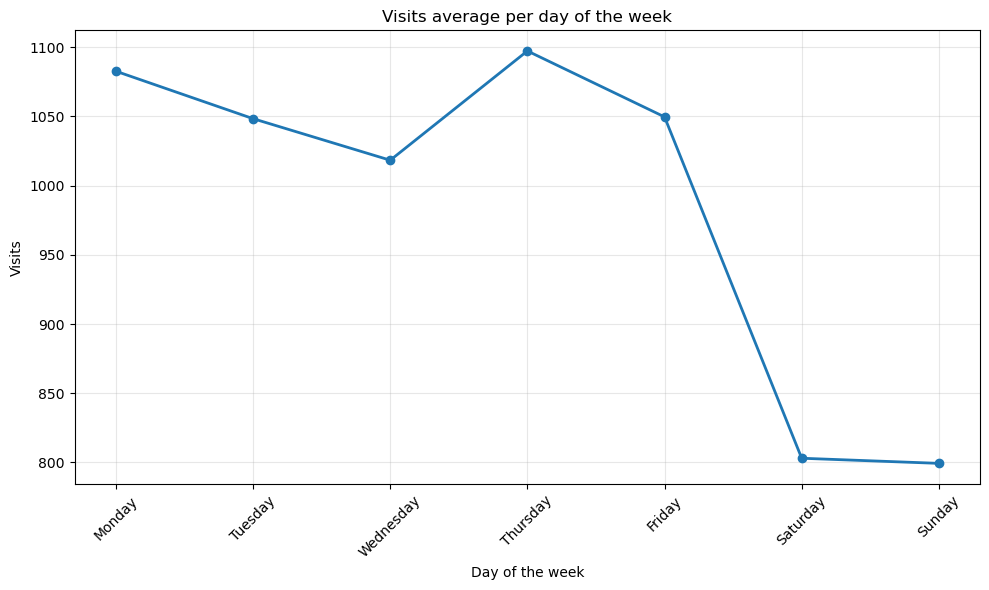

In [8]:
# Conteo de visitas por día (se considera que un mismo usuario puede ter más de 1 visita al día)
visits_by_year_week_dow = visits.groupby(['year','week','dow']).agg({'Uid':'count'}).reset_index()
mean_visits_by_week_dow = visits_by_year_week_dow.groupby(['week','dow']).agg({'Uid':'mean'}).reset_index()
mean_visits_by_dow = mean_visits_by_week_dow.groupby('dow').agg({'Uid':'mean'}).reset_index()

# Mostrar resumen de usuarios únicos
print("=== VISITS PER DAY ANALYSIS ===")
print(f"Daily average: {mean_visits_by_dow['Uid'].mean():.0f} visits")

#Definición de gráficos para el reporte
plt.figure(figsize=(10, 6))
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.plot(mean_visits_by_dow['dow'], mean_visits_by_dow['Uid'], marker='o', linewidth=2)
plt.title('Visits average per day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Visits')
plt.xticks(range(7), days, rotation=45)
plt.grid(True, alpha=0.3)

#Impresión de gráficos
plt.tight_layout()
plt.show()

### 📈 Hallazgos Clave:

- **Tendencia general y estacionalidades**:
    - El comportamiento de la gráfica de usuarios únicos y visitas por día tienen comportamiento muy similares. Resulta nuevamente que los días lunes y miércoles son los días en los que existe un mayor número de visitas a la plataforma.


### ¿Cuál es la duración de cada sesión?

#### Análisis general de número de visitas a plataforma por día, semana y mes

In [9]:
# Definición de función para verificar duración de visitas
def visit_length(dataframe):
    visit_length_max = dataframe['visit_length_s'].max()
    visit_length_min = dataframe['visit_length_s'].min()
    visit_length_mean = dataframe['visit_length_s'].mean()
    print("=== VISITS DURATION RESUME ===")
    print(f"Average duration: {visit_length_mean:.0f} seconds")
    print(f"Minimum duration: {visit_length_min:.0f} seconds")
    print(f"Maximum duration: {visit_length_max:.0f} seconds")

# Uso de función para mostrar resumen de duración de sesiones
visit_length(visits)

=== VISITS DURATION RESUME ===
Average duration: 643 seconds
Minimum duration: -2760 seconds
Maximum duration: 42660 seconds


Se detecta un comportamiento inesperado de valor negativo en la duración mínima. Se decide verificar si existen registros de sesiones con duración negativa, es decir, con un valor de tiempo mayor para Start_Ts respecto de End_Ts

In [10]:
# Verificar si hay duraciones negativas
negative_durations = visits[visits['visit_length_s'] < 0]
print("There is a quantity of",len(negative_durations),"visits with negative duration")

There is a quantity of 2 visits with negative duration


Se decide eliminar dichas sesiones para evitar que sigan afectando a los resultados.

In [11]:
# Filtrar solo sesiones con duración positiva
visits_clean = visits[visits['visit_length_s'] >= 0]
print(f"Original visits: {len(visits)}")
print(f"Visits after cleaning: {len(visits_clean)}")

Original visits: 359400
Visits after cleaning: 359398


Ya con la eliminación de registros de visitas con duración negativa, ahora sí se vuelve a hacer la determinación de la duración de una visita.

In [12]:
# Uso de función para mostrar resumen de duración de sesiones
visit_length(visits_clean)

=== VISITS DURATION RESUME ===
Average duration: 643 seconds
Minimum duration: 0 seconds
Maximum duration: 42660 seconds


Se detecta que el valor mínimo esperado de duración que puede tener una visita es de 0 segundos, lo que en otras palabras significa que existen registros de visitas sonde Start_Ts y End_Ts son iguales. Para confirmar la teoría, se verifica que existan estos registros.

In [13]:
# Verificar si hay duraciones nulas
null_durations = visits_clean[visits_clean['visit_length_s'] == 0]
print("There is a quantity of",len(null_durations),"visits with null duration")

There is a quantity of 35794 visits with null duration


#### Análisis comparativo entre fuentes de anuncios de la duración de las visitas

In [14]:
print("Analysis for ad source 1")
visit_length((visits_slices['source_1'])[visits_slices['source_1']['visit_length_s'] >= 0])
print("Analysis for ad source 2")
visit_length((visits_slices['source_2'])[visits_slices['source_2']['visit_length_s'] >= 0])
print("Analysis for ad source 3")
visit_length((visits_slices['source_3'])[visits_slices['source_3']['visit_length_s'] >= 0])
print("Analysis for ad source 4")
visit_length((visits_slices['source_4'])[visits_slices['source_4']['visit_length_s'] >= 0])
print("Analysis for ad source 5")
visit_length((visits_slices['source_5'])[visits_slices['source_5']['visit_length_s'] >= 0])
print("Analysis for ad source 6")
visit_length((visits_slices['source_6'])[visits_slices['source_6']['visit_length_s'] >= 0])
print("Analysis for ad source 7")
visit_length((visits_slices['source_7'])[visits_slices['source_7']['visit_length_s'] >= 0])
print("Analysis for ad source 9")
visit_length((visits_slices['source_9'])[visits_slices['source_9']['visit_length_s'] >= 0])
print("Analysis for ad source 10")
visit_length((visits_slices['source_10'])[visits_slices['source_10']['visit_length_s'] >= 0])

Analysis for ad source 1
=== VISITS DURATION RESUME ===
Average duration: 1039 seconds
Minimum duration: 0 seconds
Maximum duration: 35760 seconds
Analysis for ad source 2
=== VISITS DURATION RESUME ===
Average duration: 845 seconds
Minimum duration: 0 seconds
Maximum duration: 31440 seconds
Analysis for ad source 3
=== VISITS DURATION RESUME ===
Average duration: 572 seconds
Minimum duration: 0 seconds
Maximum duration: 42660 seconds
Analysis for ad source 4
=== VISITS DURATION RESUME ===
Average duration: 560 seconds
Minimum duration: 0 seconds
Maximum duration: 22860 seconds
Analysis for ad source 5
=== VISITS DURATION RESUME ===
Average duration: 527 seconds
Minimum duration: 0 seconds
Maximum duration: 18360 seconds
Analysis for ad source 6
=== VISITS DURATION RESUME ===
Average duration: 1370 seconds
Minimum duration: 0 seconds
Maximum duration: 5940 seconds
Analysis for ad source 7
=== VISITS DURATION RESUME ===
Average duration: 607 seconds
Minimum duration: 0 seconds
Maximum d

#### Análisis comparativo entre fuentes de anuncios de la duración de las visitas

In [15]:
print("Analysis for device desktop")
visit_length((visits_slices_per_devices['desktop'])[visits_slices_per_devices['desktop']['visit_length_s'] >= 0])
print("Analysis for deviceo touch")
visit_length((visits_slices_per_devices['touch'])[visits_slices_per_devices['touch']['visit_length_s'] >= 0])

Analysis for device desktop
=== VISITS DURATION RESUME ===
Average duration: 703 seconds
Minimum duration: 0 seconds
Maximum duration: 42660 seconds
Analysis for deviceo touch
=== VISITS DURATION RESUME ===
Average duration: 480 seconds
Minimum duration: 0 seconds
Maximum duration: 30840 seconds



### 📈 Hallazgos Clave:

- **Tendencia general**:
    - Una visita en la plataforma de Showz tiene una duración máxima registrada de 42660 segundos, que es igual a 711 minutos, o a casi 12 horas.
    - Una visita en la plataforma de Showz tiene una duración mínima registrada de 0 segundos.
    - La visita en la plataforma de Showz por el promedio de los clientes tiene una duración promedio de 643 segundos.
    - Las fuentes de anuncios que han generado las visitas con una duración cercana a las duraciones promedio en general han sido: 6, 1, 2, y 10. En el mismo orden que fueron escritas es el orden de mejor a peor fuente de anuncios.
    -  Las fuentes de anuncios que han generado las visitas con las mayores duraciones han sido: 3, 1 y 2. En el mismo orden que fueron escritas las fuentes de anuncios es el orden de mayores tiempos de duración de las visitas.
    - Las fuentes de anuncios que han generado las visitas con las menores duraciones han sido: 7 y 6. En el mismo orden que fueron escritas las fuentes de anuncios es el orden de menores tiempos de duración de las visitas.

### ¿Con qué frecuencia los usuarios regresan?

Para poder hacer el análisis de las tasas de retención, se considerará el uso de cohortes por la fecha de la primer visita de cada cliente, y se hará el seccionamiento con base en meses.

#### Análisis general de frecuencias de retorno de usuarios

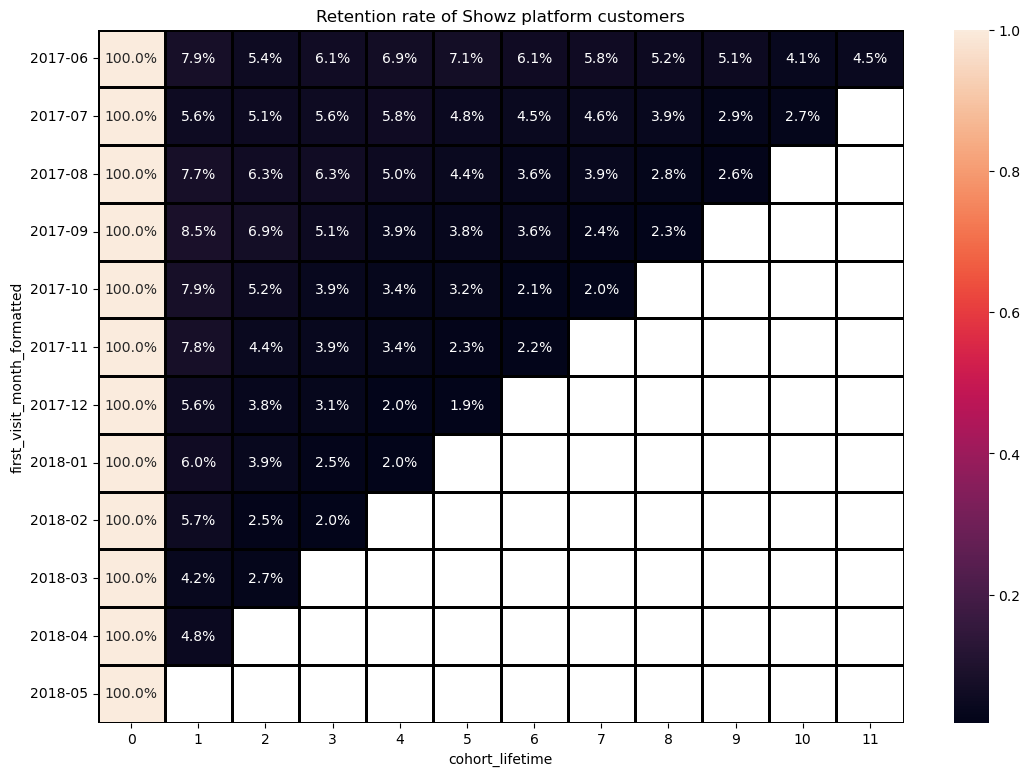

In [16]:
# Función para generar la fecha de la primer orden de cada cliente
def find_first_visit_dates(df, column_name1='Uid', column_name2='Start_Ts'):
    first_visit_dates = df.groupby('Uid')['Start_Ts'].min()
    first_visit_dates.name = 'first_visit_date'
    df = df.join(first_visit_dates, on='Uid')
    return df

# Función para generar cohortes acorde a la fecha de la primera visita del cliente y se secciona por mes
def create_order_dates_cohortes(df, column_name1='Start_Ts', column_name2='first_visit_date', column_name3='Uid'):
    df['visit_month'] = pd.DatetimeIndex(df[column_name1]).to_period('M').to_timestamp()
    df['first_visit_month'] = pd.DatetimeIndex(df[column_name2]).to_period('M').to_timestamp()
    cohorts = df.groupby(['first_visit_month', 'visit_month']).agg({column_name3: 'nunique'}).reset_index()
    cohorts['cohort_lifetime'] = cohorts['visit_month'] - cohorts['first_visit_month']
    cohorts['cohort_lifetime'] = cohorts['cohort_lifetime'] / np.timedelta64(30, 'D')
    cohorts['cohort_lifetime'] = cohorts['cohort_lifetime'].round().astype('int')
    return cohorts

# Función para determinar no. de usuarios activos en la fecha de las cohortes y tasa de retención
def initial_users_retention(df, column_name1='cohort_lifetime', column_name2='first_visit_month', column_name3='Uid'):
    initial_users_count = df[df[column_name1]==0][[column_name2, column_name3]]
    initial_users_count = initial_users_count.rename(columns={column_name3:'cohort_users'})
    df = df.merge(initial_users_count,on=column_name2)
    df['retention'] = df[column_name3]/df['cohort_users']
    return df
    
# Función para generar mapa de calor
def heatmap_retention(df, column_name1='first_visit_month', column_name2='retention', columns='cohort_lifetime'):
    """
    Genera mapa de calor de tasa de retención de tabla pivot generada
    
    Args:
        dataframe: DataFrame a analizar con cohortes
        column_name1: columna de los meses de la fecha de la primer orden
        columns: Valores para las columnas
        
    Returns:
        graph: figura del gráfico de calor de tasa de retención 
    """
    # formateo de fechas de columna first_visit_month
    df['first_visit_month_formatted'] = df[column_name1].dt.strftime('%Y-%m')

    # Generación de tabla pivot para la tasa de retención
    retention_pivot = df.pivot_table(
        index='first_visit_month_formatted',
        columns=columns,
        values=column_name2,
        aggfunc='mean'
    )

    # Generación de mapa de calor
    plt.figure(figsize=(13,9))
    plt.title('Retention rate of Showz platform customers')
    sns.heatmap(
        retention_pivot,
        annot=True,
        fmt='.1%',
        linewidths=1,
        linecolor='black'
    )
    plt.yticks(rotation=0)
    plt.show()

#Uso de funciones generadas
visits = find_first_visit_dates(visits)
cohorts = create_order_dates_cohortes(visits)
cohorts = initial_users_retention(cohorts)
heatmap_retention(cohorts)

#### Análisis comparativo entre fuentes de anuncios de frecuencia de retorno de usuarios

heatmap of retention rate for visits with source 1


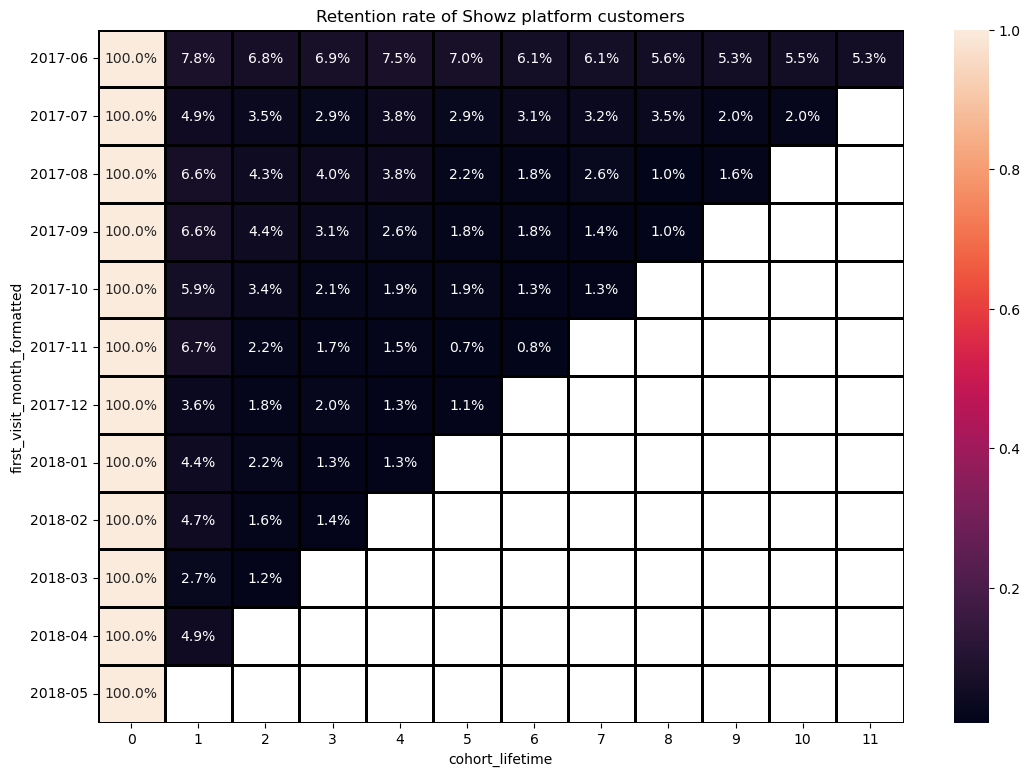

heatmap of retention rate for visits with source 2


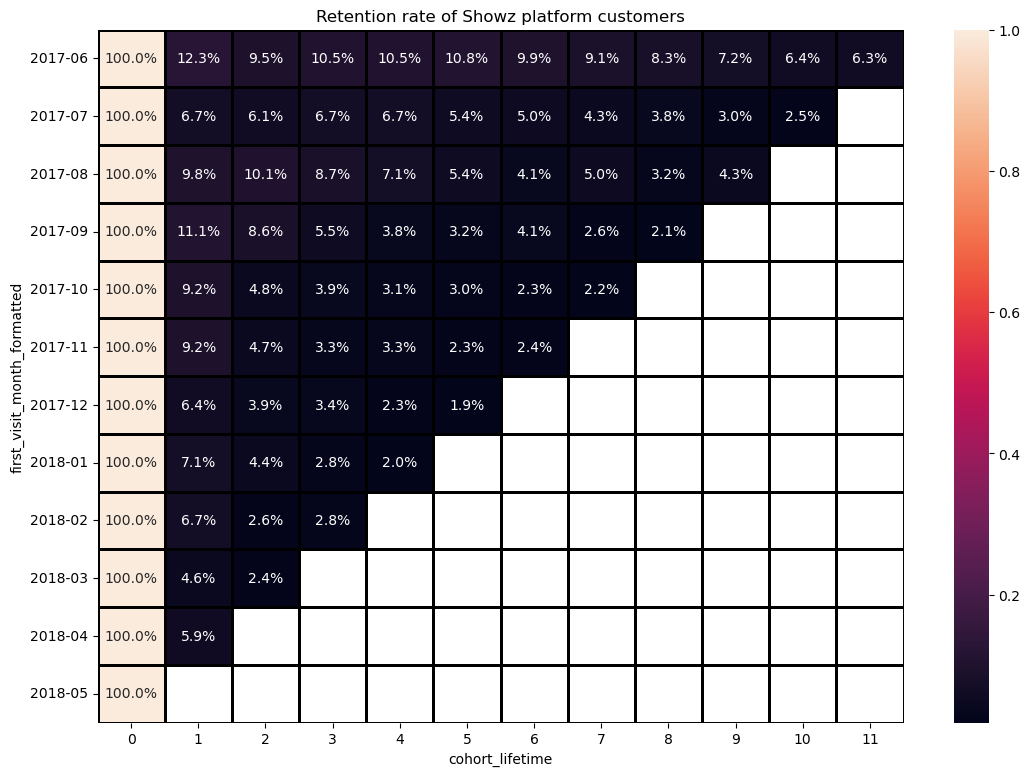

heatmap of retention rate for visits with source 3


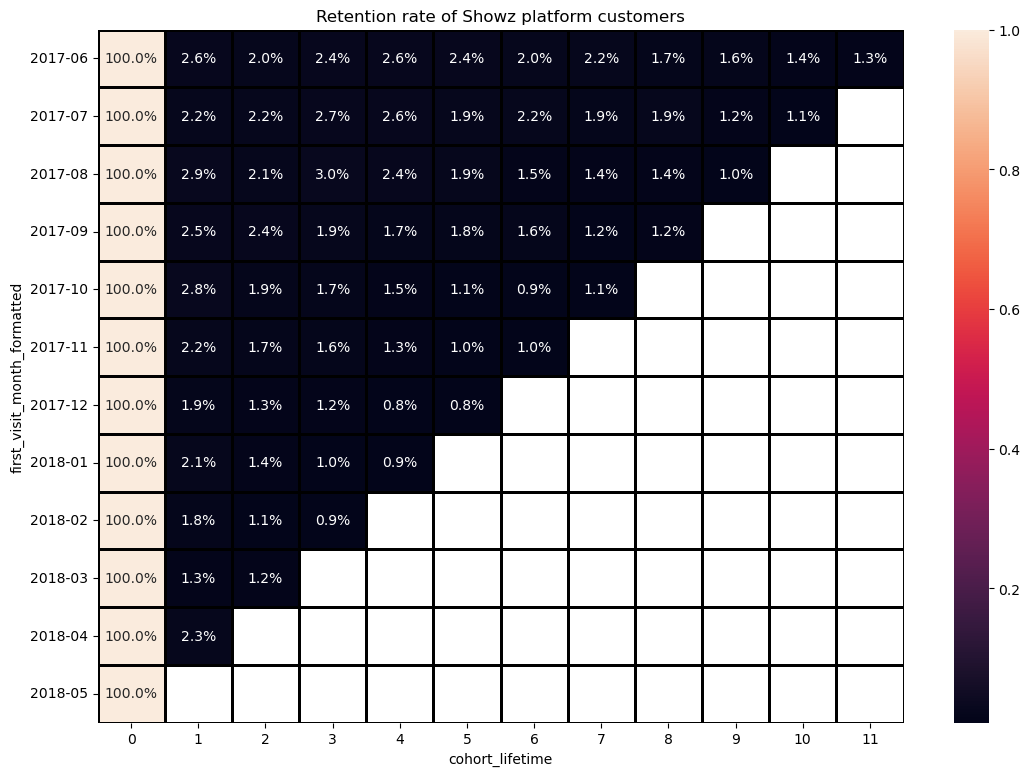

heatmap of retention rate for visits with source 4


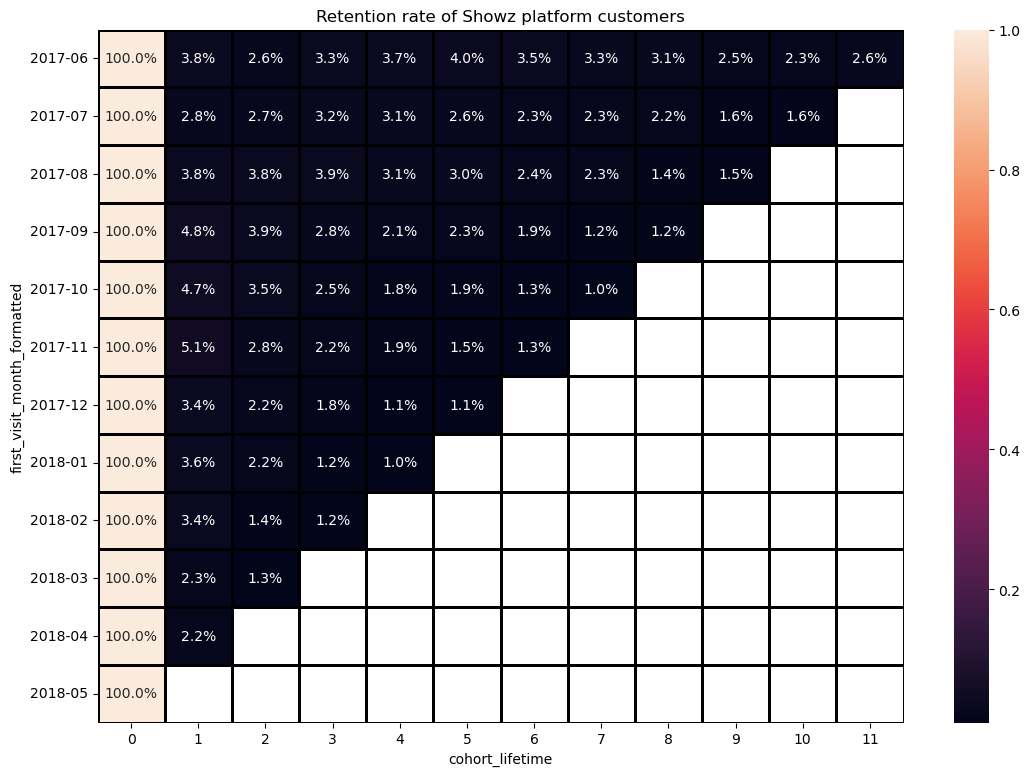

heatmap of retention rate for visits with source 5


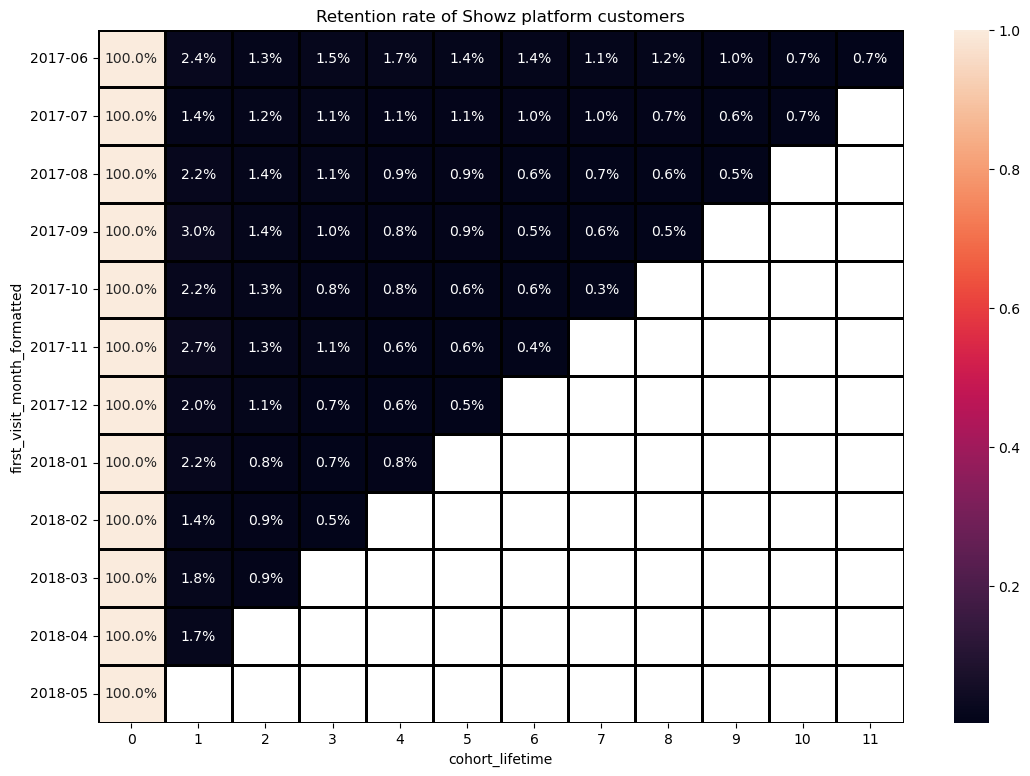

heatmap of retention rate for visits with source 6


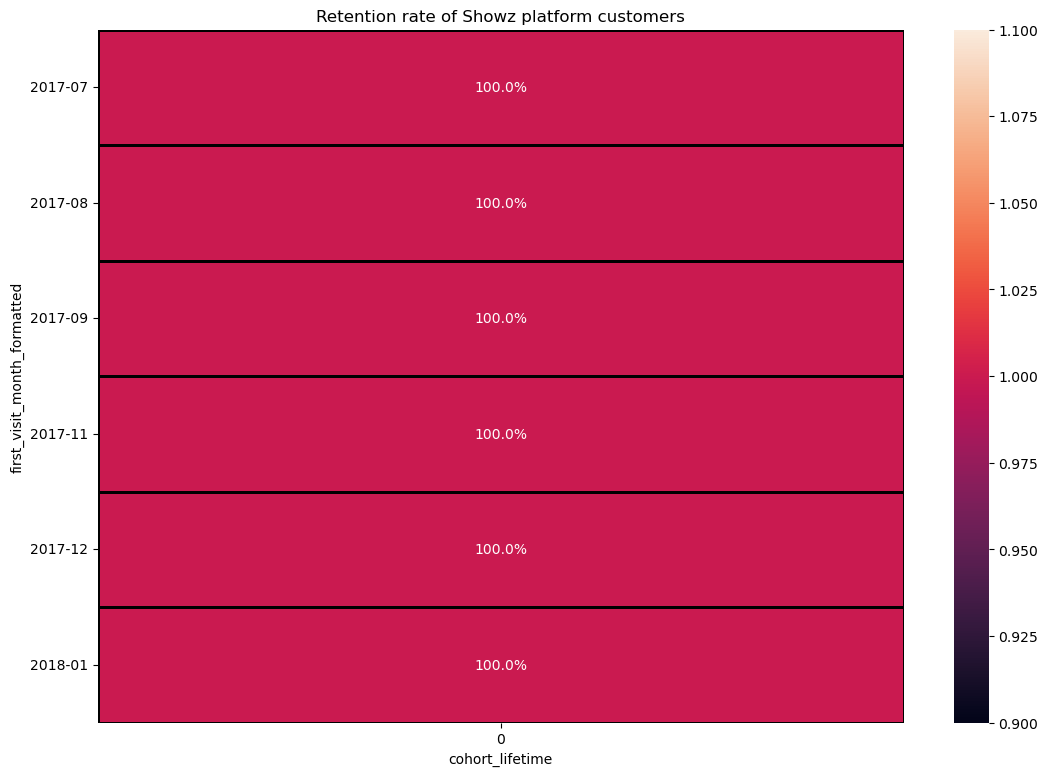

heatmap of retention rate for visits with source 7


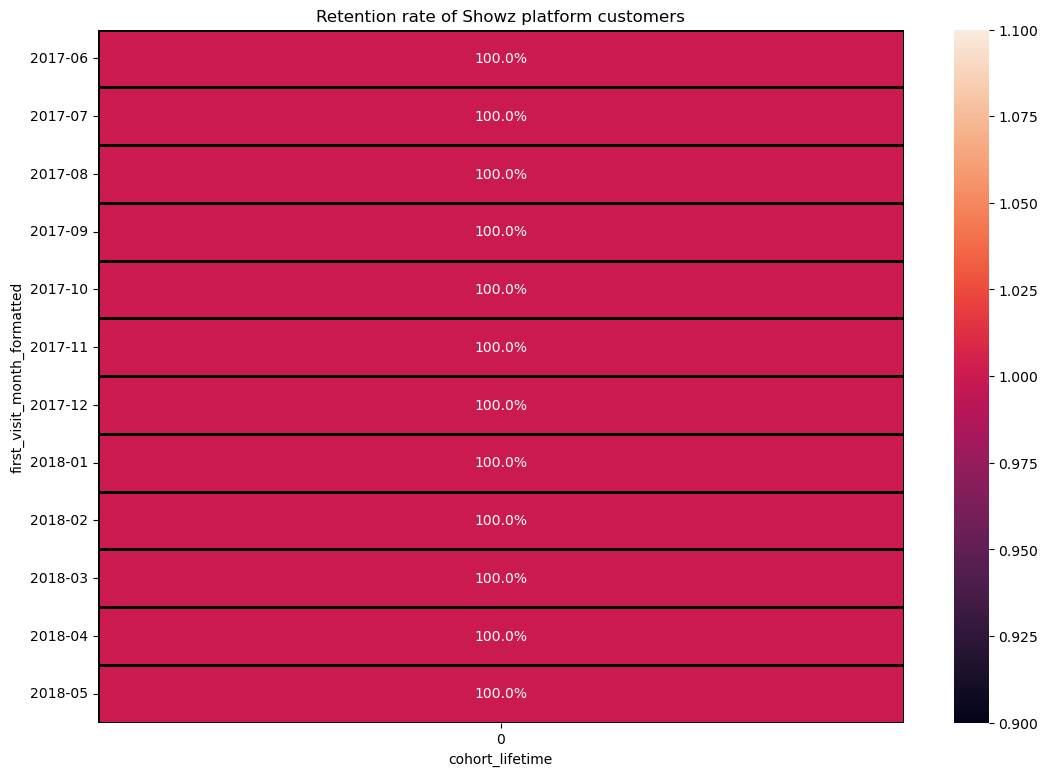

heatmap of retention rate for visits with source 9


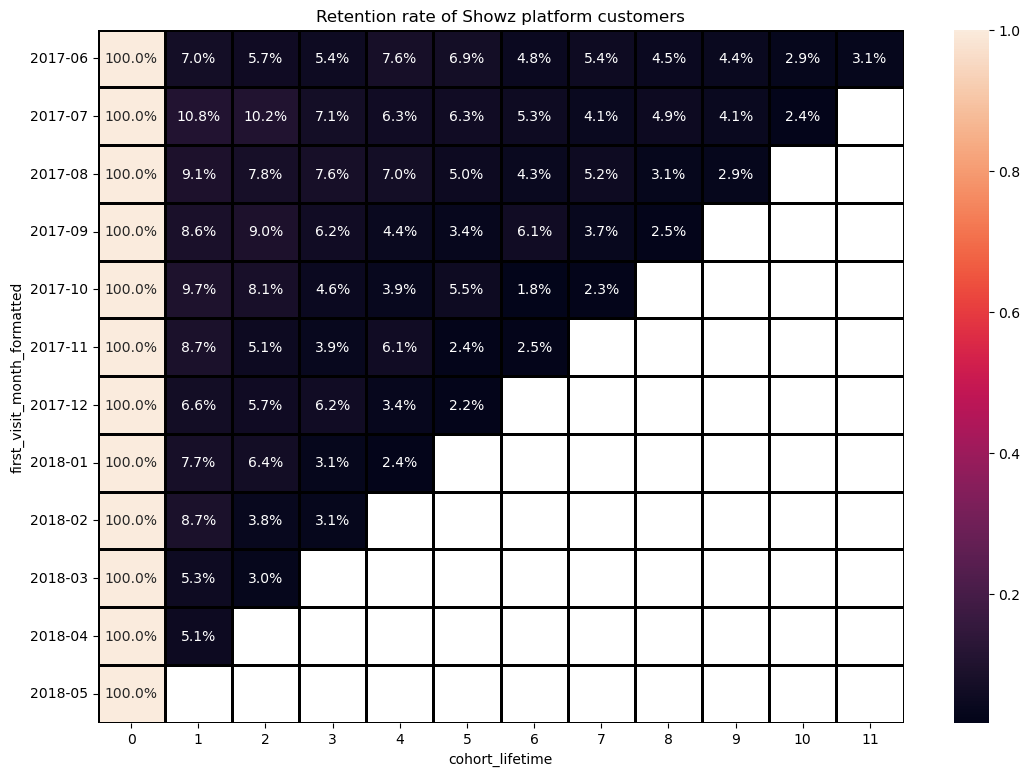

heatmap of retention rate for visits with source 10


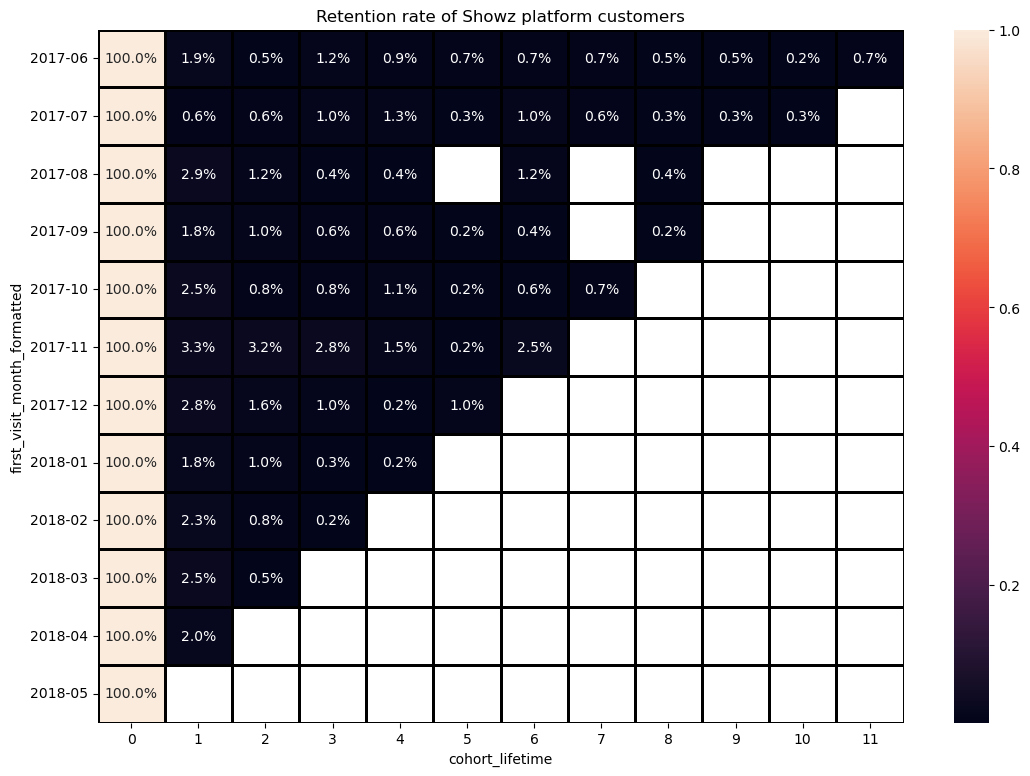

In [17]:
#Uso de funciones en cada una de las slices de visits por source

visits_slices['source_1']=find_first_visit_dates(visits_slices['source_1'])
visits_slices['source_2']=find_first_visit_dates(visits_slices['source_2'])
visits_slices['source_3']=find_first_visit_dates(visits_slices['source_3'])
visits_slices['source_4']=find_first_visit_dates(visits_slices['source_4'])
visits_slices['source_5']=find_first_visit_dates(visits_slices['source_5'])
visits_slices['source_6']=find_first_visit_dates(visits_slices['source_6'])
visits_slices['source_7']=find_first_visit_dates(visits_slices['source_7'])
visits_slices['source_9']=find_first_visit_dates(visits_slices['source_9'])
visits_slices['source_10']=find_first_visit_dates(visits_slices['source_10'])

cohorts_1 = create_order_dates_cohortes(visits_slices['source_1'])
cohorts_2 = create_order_dates_cohortes(visits_slices['source_2'])
cohorts_3 = create_order_dates_cohortes(visits_slices['source_3'])
cohorts_4 = create_order_dates_cohortes(visits_slices['source_4'])
cohorts_5 = create_order_dates_cohortes(visits_slices['source_5'])
cohorts_6 = create_order_dates_cohortes(visits_slices['source_6'])
cohorts_7 = create_order_dates_cohortes(visits_slices['source_7'])
cohorts_9 = create_order_dates_cohortes(visits_slices['source_9'])
cohorts_10 = create_order_dates_cohortes(visits_slices['source_10'])

cohorts_1 = initial_users_retention(cohorts_1)
cohorts_2 = initial_users_retention(cohorts_2)
cohorts_3 = initial_users_retention(cohorts_3)
cohorts_4 = initial_users_retention(cohorts_4)
cohorts_5 = initial_users_retention(cohorts_5)
cohorts_6 = initial_users_retention(cohorts_6)
cohorts_7 = initial_users_retention(cohorts_7)
cohorts_9 = initial_users_retention(cohorts_9)
cohorts_10 = initial_users_retention(cohorts_10)

print("heatmap of retention rate for visits with source 1")
heatmap_retention(cohorts_1)
print("heatmap of retention rate for visits with source 2")
heatmap_retention(cohorts_2)
print("heatmap of retention rate for visits with source 3")
heatmap_retention(cohorts_3)
print("heatmap of retention rate for visits with source 4")
heatmap_retention(cohorts_4)
print("heatmap of retention rate for visits with source 5")
heatmap_retention(cohorts_5)
print("heatmap of retention rate for visits with source 6")
heatmap_retention(cohorts_6)
print("heatmap of retention rate for visits with source 7")
heatmap_retention(cohorts_7)
print("heatmap of retention rate for visits with source 9")
heatmap_retention(cohorts_9)
print("heatmap of retention rate for visits with source 10")
heatmap_retention(cohorts_10)

#### Análisis comparativo entre dispositivos de frecuencia de retorno de usuarios

heatmap of retention rate for visits with device desktop


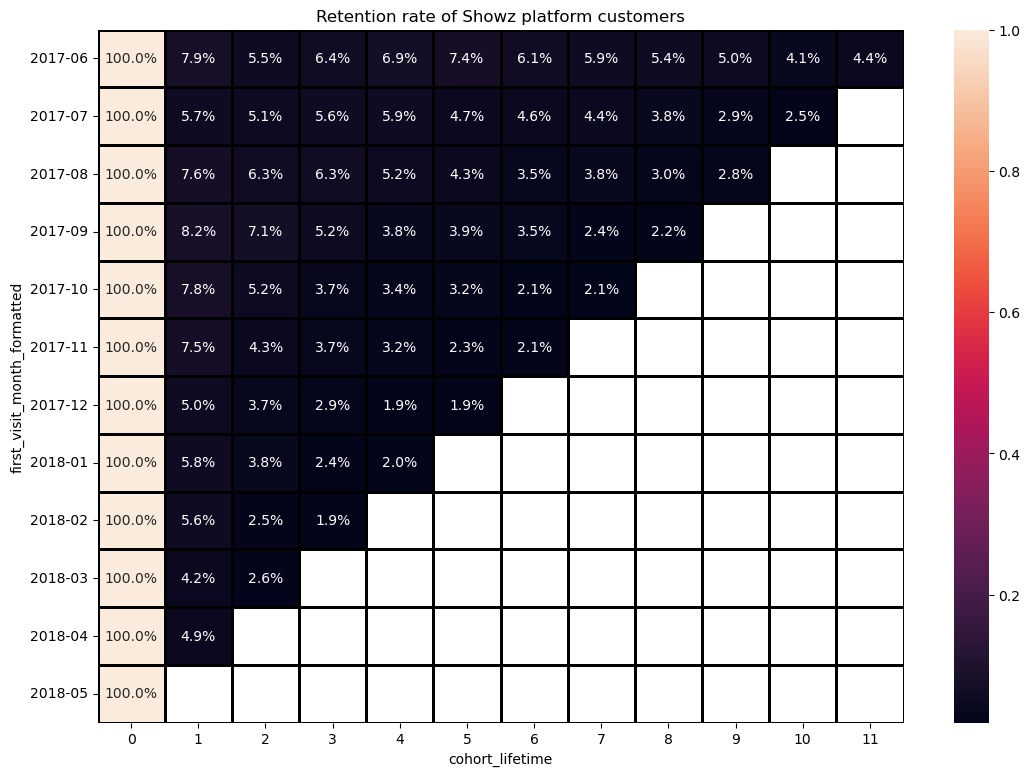

heatmap of retention rate for visits with device touch


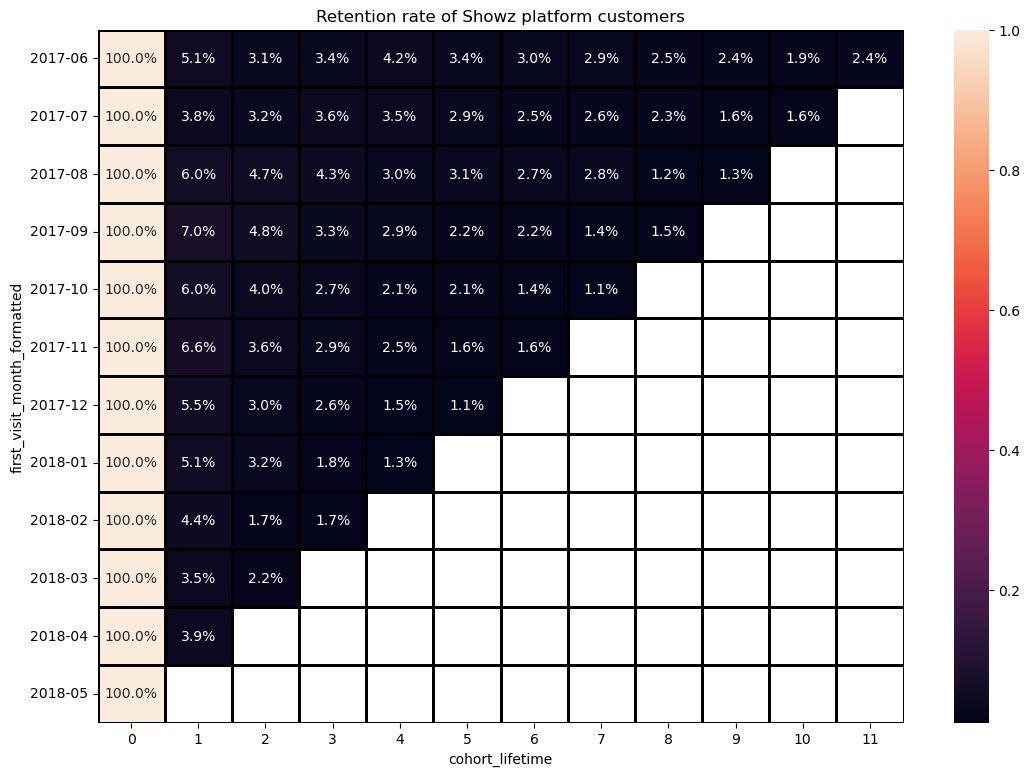

In [18]:
#Uso de funciones en cada una de las slices de visits por devices

visits_slices_per_devices['desktop']=find_first_visit_dates(visits_slices_per_devices['desktop'])
visits_slices_per_devices['touch']=find_first_visit_dates(visits_slices_per_devices['touch'])

cohorts_desktop = create_order_dates_cohortes(visits_slices_per_devices['desktop'])
cohorts_touch = create_order_dates_cohortes(visits_slices_per_devices['touch'])

cohorts_desktop = initial_users_retention(cohorts_desktop)
cohorts_touch = initial_users_retention(cohorts_touch)

print("heatmap of retention rate for visits with device desktop")
heatmap_retention(cohorts_desktop)
print("heatmap of retention rate for visits with device touch")
heatmap_retention(cohorts_touch)

### 📈 Hallazgos Clave:

**Tendencia general**:
- Se puede percibir que para cada cohorte, todos sus ciclos de vida cuentan con una tasa de retención menor a 0.1 (10%), lo cual nos dice que para cada 100 personas que visitan la plataforma de Showz, menos de 10 personas vuelven al siguiente mes a visitar la plataforma. Se puede entender porque:
    - Los usuarios compran entradas cuando hay un evento que les interesa.
    - No es un servicio de suscripción: No hay necesidad de regresar mensualmente.
    - Comportamiento estacional: Muchos eventos son estacionales (conciertos de verano, obras de teatro en temporadas específicas)
- Para el análisis comparativo de fuentes de anuncios, se puede percibir que aunque seguimos percibiendo porcentajes bajos de tasas de retención, las fuentes que representan un mejor desempeño son las fuentes con id 2 y 9.
- Por otra parte, las fuentes que representan un peor desempeño por tener las menores tasas de retención son las fuentes con id 1, 3, 4, 5 y 10.
- Como dato adicional, se puede percibir que las fuentes de anuncios con id 6 y 7 cuentan con un solo ciclo de vida (el inicial, o número 0), aún considerando que el mapa de calor cuenta con índices de distintos meses, o dicho de otra forma, nuestros datos cuentan con registros de visitas relacionados a esas fuentes de anuncios donde los clientes tuvieron una primer visita, y esos mismos clientes no volvieron a visitar la plataforma debido a esas fuentes de anuncios.

## 2. Ventas

### Funciones de utilidad para generación de slices

Como premisa previa a realizar el análisis, es importante hacer notar que el dataframe de "orders" no cuenta con el detalle de cuál fue la fuente de anuncios o dispositivo mediante la cual el cliente se acercó a realizar su compra. Para poder determinar esto, se hará uso del dataframe "visits", el cual si cuenta con el dato de la fuente de anuncios y dispositivos mediante la cual cada cliente ingresó a la plataforma. Además, no existe algún dato certero que nos diga cuál fue la fuente de anuncio o dispositivo para cada cliente en cada una de sus compras, puesto que un mismo cliente podría haber ingresado a la plataforma por medios diferentes entre compras. Para ello, se basará el análisis con base en que cada orden realizada tuvo como fuente de anuncio y dispositivo los mismos que la visita más reciente previa a la fecha de la compra.

In [19]:
# Función para generar slices de dataframes de orders, con base en los posibles valores de una determinada columna
def create_dataframe_slices(dataframe, column_name):
    """
    Genera slices del dataframe por cada valor único de la columna especificada
    
    Args:
        dataframe: DataFrame a dividir en slices
        column_name: Nombre de la columna de referencia para crear los slices
        
    Returns:
        dict: Diccionario donde las keys son los valores únicos de la columna
              y los values son los DataFrames correspondientes
    """
    slices_dict = {}
    unique_values = dataframe[column_name].unique()
    
    for value in unique_values:
        # Usar el valor directamente como key del diccionario
        slices_dict[value] = dataframe[dataframe[column_name] == value]
    
    return slices_dict

# Función para, por cada compra, encontrar la fuente de anuncio de la visita más reciente antes de esa compra
def get_latest_source_before_purchase(orders_df, visits_df):
    result = []
    
    for _, order in orders_df.iterrows():
        user_visits = visits_df[visits_df['Uid'] == order['Uid']]
        # Filtrar visitas antes de la compra
        visits_before_purchase = user_visits[user_visits['Start_Ts'] <= order['Buy_Ts']]
        
        if not visits_before_purchase.empty:
            # Obtener la visita más reciente
            latest_visit = visits_before_purchase.loc[visits_before_purchase['Start_Ts'].idxmax()]
            result.append({
                'Uid': order['Uid'],
                'Buy_Ts': order['Buy_Ts'],
                'Revenue': order['Revenue'],
                'Source_Id': latest_visit['Source_Id']
            })
    
    return pd.DataFrame(result)

# Función para, por cada compra, encontrar el dispositivo de la visita más reciente antes de esa compra
def get_latest_device_before_purchase(orders_df, visits_df):
    result = []
    
    for _, order in orders_df.iterrows():
        user_visits = visits_df[visits_df['Uid'] == order['Uid']]
        # Filtrar visitas antes de la compra
        visits_before_purchase = user_visits[user_visits['Start_Ts'] <= order['Buy_Ts']]
        
        if not visits_before_purchase.empty:
            # Obtener la visita más reciente
            latest_visit = visits_before_purchase.loc[visits_before_purchase['Start_Ts'].idxmax()]
            result.append({
                'Uid': order['Uid'],
                'Buy_Ts': order['Buy_Ts'],
                'Revenue': order['Revenue'],
                'Source_Id': order['Source_Id'],
                'Device': latest_visit['Device']
            })
    
    return pd.DataFrame(result)

### ¿Cuánto tiempo pasa para que la gente realice su primer compra?

#### Análisis general de tiempo de conversión de clientes

The time average between log in and conversion of customers is about: 17 days
The time mode between log in and conversion of customers is about: 0 days


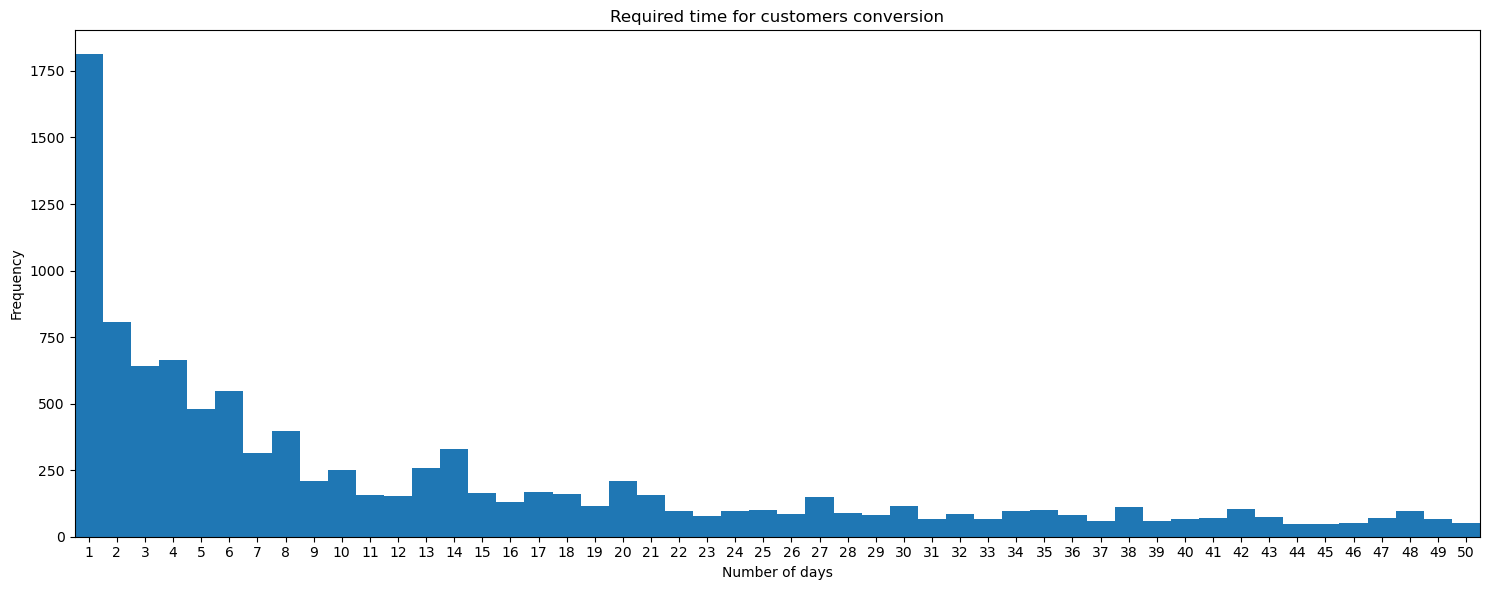

In [20]:
# Determinación de la primer compra de los clientes
first_purchase_dates = orders.groupby('Uid')['Buy_Ts'].min()

first_purchase_dates.name = 'first_purchase_date'
orders = orders.join(first_purchase_dates, on='Uid')


# Traslado de primeras visitas a datraframe de órdenes
necessary_columns = visits[['Uid', 'first_visit_date']].drop_duplicates()
orders = orders.merge(necessary_columns, on='Uid', how='left')

# Definición de tiempo de conversión
orders['conversion_time'] = (orders['first_purchase_date']-orders['first_visit_date'])
mean_conversion_time = orders['conversion_time'].mean().floor('D')
conversion_time_mode = orders['conversion_time'].mode()
print('The time average between log in and conversion of customers is about:',mean_conversion_time.days, 'days')
print('The time mode between log in and conversion of customers is about:',conversion_time_mode[0].days, 'days')

# Generación de histograma de días requeridos para conversión
# Crear 50 bins desde 0.5 hasta 50.5 para que cada día tenga su propia barra
bins = np.arange(0.5, 51.5, 1)
plt.figure(figsize=(15, 6))
orders['conversion_time'].dt.days.plot(kind='hist', bins=bins)
plt.title('Required time for customers conversion')
plt.xlabel('Number of days')
plt.xticks(range(1, 51))  # Marcas de 1 a 50
plt.xlim(0.5, 50.5)       # Límites del eje X
plt.tight_layout()
plt.show()

#### Análisis comparativo entre fuentes de anuncios de tiempos de conversión de los clientes

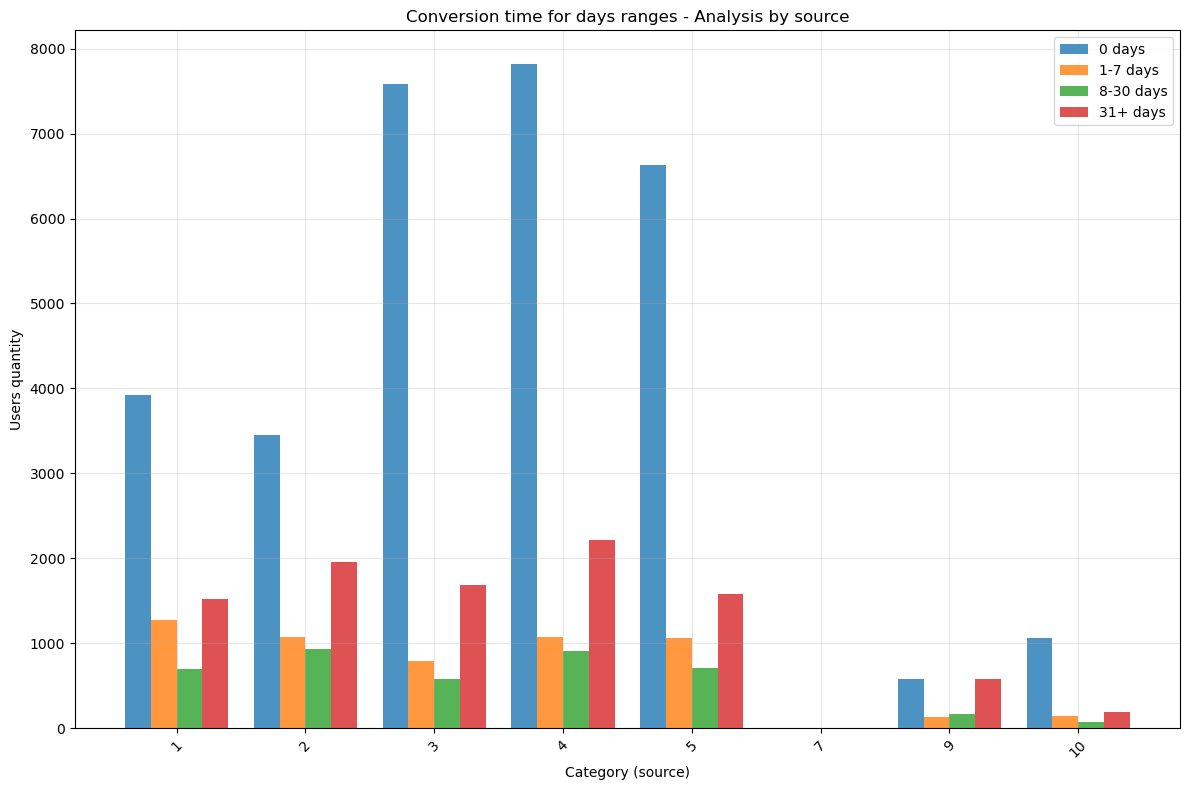

day_range,0 days,1-7 days,8-30 days,31+ days
Category_Id,,,,
1,3928.0,1270.0,703.0,1526.0
2,3454.0,1070.0,935.0,1953.0
3,7584.0,792.0,575.0,1687.0
4,7824.0,1074.0,914.0,2216.0
5,6627.0,1063.0,704.0,1577.0
7,1.0,0.0,0.0,0.0
9,581.0,129.0,169.0,585.0
10,1068.0,139.0,74.0,193.0


In [21]:
# Función para determinar fechas de primera orden para los dataframes hechos slices
def add_first_purchase_dates_to_slices(dataframes_dict):
    """
    Aplica el procesamiento de 
primera compra a cada DataFrame en el diccionario
    
    Args:
        dataframes_dict: Diccionario donde las keys son identificadores 
                        y los values son D
ataFrames de órdenes
        
    Returns:
        dict: Diccionario con los mismos keys pero DataFrames procesados
              (con columna 'first_purchase_date' agregada)
    """
    processed_dict = {}
    
    for key, df in dataframes_dict.items():
        # Crear una copia para no modificar el original
        df_copy = df.copy()
        
        # Aplicar la misma lógica del código original
        first_purchase_dates = df_copy.groupby('Uid')['Buy_Ts'].min()
        first_purchase_dates.name = 'first_purchase_date'
        df_processed = df_copy.join(first_purchase_dates, on='Uid')
        
        # Guardar el DataFrame procesado
        processed_dict[key] = df_processed
    
    return processed_dict

# Función para añadir first_visit_dates a cada Dataframe hecho slice
def add_visit_info_to_slices(dataframes_dict, visits_df):
    """
    Aplica el merge con información de visitas a cada DataFrame en el diccionario
    
    Args:
        dataframes_dict: Diccionario donde las keys son identificadores 
                        y los values son DataFrames de órdenes
        visits_df: DataFrame de visitas que contiene la información a agregar
        
    Returns:
        dict: Diccionario con los mismos keys pero DataFrames procesados
              (con columnas de visits agregadas)
    """
    processed_dict = {}
    
    # Preparar las columnas necesarias una sola vez
    necessary_columns = visits_df[['Uid', 'first_visit_date']].drop_duplicates()
    
    for key, df in dataframes_dict.items():
        # Crear una copia para no modificar el original
        df_copy = df.copy()
        
        # Aplicar el merge con la información de visitas
        df_processed = df_copy.merge(necessary_columns, on='Uid', how='left')
        
        # Guardar el DataFrame procesado
        processed_dict[key] = df_processed
    
    return processed_dict

# Función para determinar tiempo de conversión y generación de gráfico de líneas para comparar sources
def process_conversion_time_by_ranges_and_make_bar_graph(orders_slices_dict, slice_type="slice"):
    """
    Analiza el tiempo de conversión agrupado por rangos de días y genera gráficos de barras agrupadas
    para múltiples categorías desde un diccionario de DataFrames
    
    Args:
        orders_slices_dict: Diccionario donde las keys son identificadores de categorías
                           y los values son DataFrames de órdenes
        slice_type: Tipo de slice para personalizar etiquetas (ej: "source", "device", etc.)
    """
    # Preparar datos consolidados de todas las categorías
    all_conversion_data = []
    
    # Procesar cada DataFrame en el diccionario
    for slice_key, orders_df in orders_slices_dict.items():
        # Crear una copia para no modificar el original
        df_copy = orders_df.copy()
        
        # Calcular tiempo de conversión en días
        df_copy['conversion_time'] = (
            df_copy['first_purchase_date'] - df_copy['first_visit_date']
        ).dt.days
        
        # Crear rangos de días
        def categorize_conversion_days(days):
            if days == 0:
                return "0 days"
            elif 1 <= days <= 7:
                return "1-7 days"
            elif 8 <= days <= 30:
                return "8-30 days"
            else:
                return "31+ days"
        
        df_copy['day_range'] = df_copy['conversion_time'].apply(categorize_conversion_days)
        
        # Usar directamente la key del diccionario como identificador
        df_copy['Category_Id'] = slice_key
        
        # Agregar a la lista consolidada
        all_conversion_data.append(df_copy[['Category_Id', 'day_range', 'Uid']])
    
    # Consolidar todos los datos
    consolidated_df = pd.concat(all_conversion_data, ignore_index=True)
    
    # Preparar datos para el gráfico de barras agrupadas
    # Contar usuarios por categoría y rango de días
    conversion_summary = consolidated_df.groupby(['Category_Id', 'day_range']).size().reset_index(name='user_count')
    
    # Crear tabla pivot para el gráfico
    pivot_data = conversion_summary.pivot(index='Category_Id', columns='day_range', values='user_count').fillna(0)
    
    # Asegurar que todas las columnas estén presentes en el orden correcto
    day_order = ["0 days", "1-7 days", "8-30 days", "31+ days"]
    for col in day_order:
        if col not in pivot_data.columns:
            pivot_data[col] = 0
    pivot_data = pivot_data[day_order]
    
    # Crear el gráfico de barras agrupadas
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Configurar el ancho de las barras y posiciones
    x = np.arange(len(pivot_data.index))
    width = 0.2
    
    # Crear barras para cada rango de días
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, (col, color) in enumerate(zip(day_order, colors)):
        ax.bar(x + i * width, pivot_data[col], width, 
               label=col, color=color, alpha=0.8)
    
    # Personalizar el gráfico
    ax.set_xlabel(f'Category ({slice_type})')
    ax.set_ylabel('Users quantity')
    ax.set_title(f'Conversion time for days ranges - Analysis by {slice_type}')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(pivot_data.index, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Mostrar el gráfico
    plt.tight_layout()
    plt.show()
    
    return pivot_data

# Aplicación de funciones
# Determinación de fuente de anuncios para cada orden
orders_with_source = get_latest_source_before_purchase(orders, visits)
# Determinación de dispositivo usado para cada orden
orders_with_source_device = get_latest_device_before_purchase(orders_with_source, visits)
# Generación de slices de orders con base en sources
orders_slices_sources = create_dataframe_slices(orders_with_source_device, 'Source_Id')
# Determinación de fechas de primera orden por cada registro de orden
orders_slices_sources = add_first_purchase_dates_to_slices(orders_slices_sources)
# Determinación de fechas de primera visita por cada registro de orden
orders_slices_sources = add_visit_info_to_slices(orders_slices_sources, visits)
# Generación de gráfico de líneas de tiempo de conversión por fuente de anuncios
process_conversion_time_by_ranges_and_make_bar_graph(orders_slices_sources, "source")

#### Análisis comparativo entre dispositivos de tiempos de conversión de los clientes

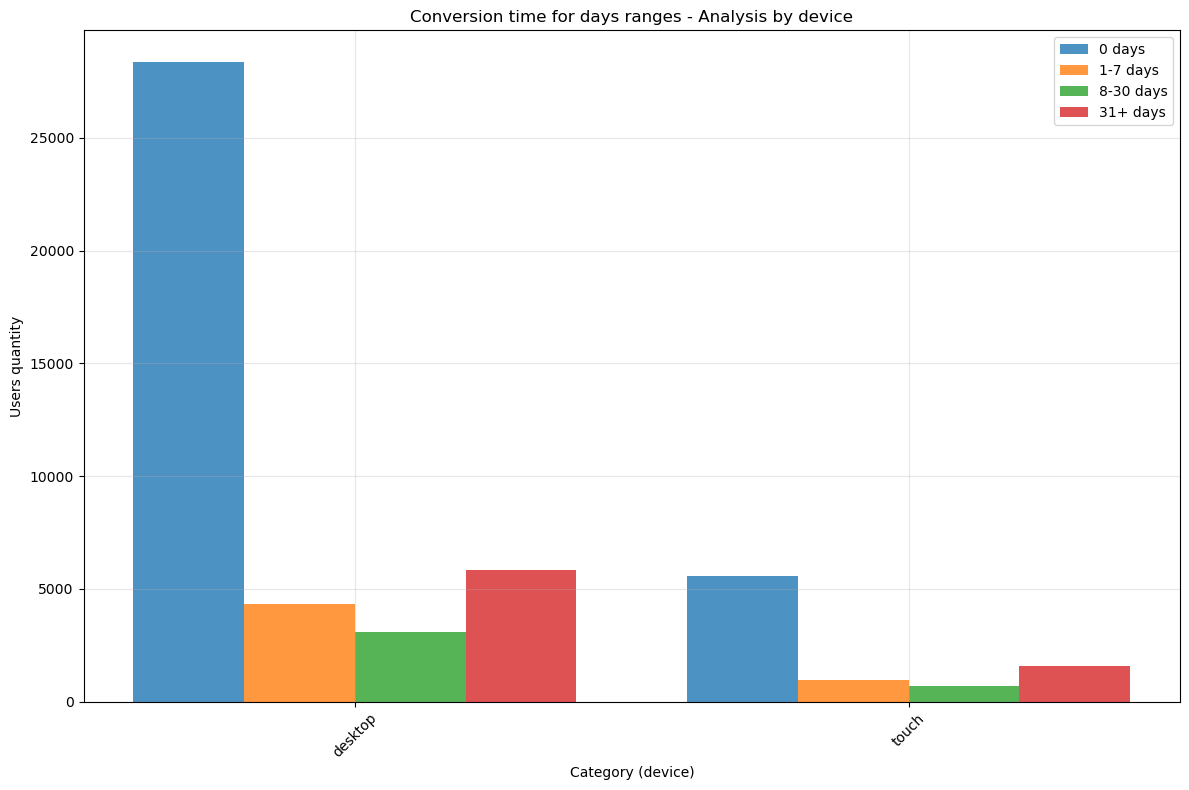

day_range,0 days,1-7 days,8-30 days,31+ days
Category_Id,,,,
desktop,28356,4332,3090,5843
touch,5576,963,686,1569


In [22]:
# Aplicación de funciones
# Generación de slices de orders con base en sources
orders_slices_devices = create_dataframe_slices(orders_with_source_device, 'Device')
# Determinación de fechas de primera orden por cada registro de orden
orders_slices_devices = add_first_purchase_dates_to_slices(orders_slices_devices)
# Determinación de fechas de primera visita por cada registro de orden
orders_slices_devices = add_visit_info_to_slices(orders_slices_devices, visits)
# Generación de gráfico de líneas de tiempo de conversión por fuente de anuncios
process_conversion_time_by_ranges_and_make_bar_graph(orders_slices_devices, "device")


### 📈 Hallazgos Clave:

**Tendencia general**:
- Se puede percibir que la distribución del número de días de transición entre registro y conversión no es de tipo normal, por lo que no se puede optar por elegir la media o la mediana como elemento tendencial.
- Acorde a la gráfica y al cálculo generado, se puede confirmar que la tendencia está en que, en mayor medida, los clientes están dentro de la categoría Conversión 0d, lo que en otras palabras nos dice que pasan 0 días entre el registro y la conversión (primera compra).
- Adicionalmente, existen los clientes que pueden llevarse 1 o más días entre registro y conversión. Mediante el gráfico podemos confirmar que la mayor parte de los clientes se encuentran bajo la media, es decir, que se llevan menos de 17 días entre su registro y su primer compra.
- Hablando del análisis por fuente de anuncios, se puede corroborar que las fuentes con mejor desempeño provocando un grupo mayor de clientes dentro del grupo Conversión 0d son las fuentes con Id 3, 4 y 5.
- Por otra parte, se puede corroborar que las fuentes con peor desempeño, provocando un grupo mayor de clientes dentro del grupo Conversión 8-30d o +31d son las fuentes con Id 1, 2, 3, 4 y 5. Si bien hay que reconocer que la diferencia entre estas fuentes no es considerable, por lo que podría pensarse que este "mal" comportamiento no es adjudicable a un mal desempeño propio de las fuentes.
- Fuentes de anuncios como las de id 6 y 7 tuvieron nula participación en la atracción de clientes, así como las fuentes 9 y 10 tuvieron una participación muy poco valiosa respecto a la generada por el resto de las fuentes.
- Hablando del análisis por dispositivos, se puede corroborar que el dispositivo con mejor desempeño provocando un grupo mayor de clientes dentro del grupo Conversión 0d fue el dispositivo desktop. Agregado a lo anterior, se puede percibir una diferencia considerable entre la participación del dispositivo desktop con el dispositivo touch para la generación de órdenes de clientes.

### ¿Cuántos pedidos hacen durante un período de tiempo dado?

#### Análisis general de número de pedidos por tiempo dado

Con base en el detalle percibido de la tasa de retención de visitas, queda claro que es muy poco recurrente que los clientes recurran a la plataforma a hacer pedidos. Por ello, y considerando que contamos con datos desde junio de 2017 a junio de 2018, se manejaran como primer propuesta un periodo de tiempo bimestral.
En dado caso que no se pueda obtener mucha información de un análisis bajo periodo bimestral, se realizará otro análisis bajo otro periodo de tiempo.

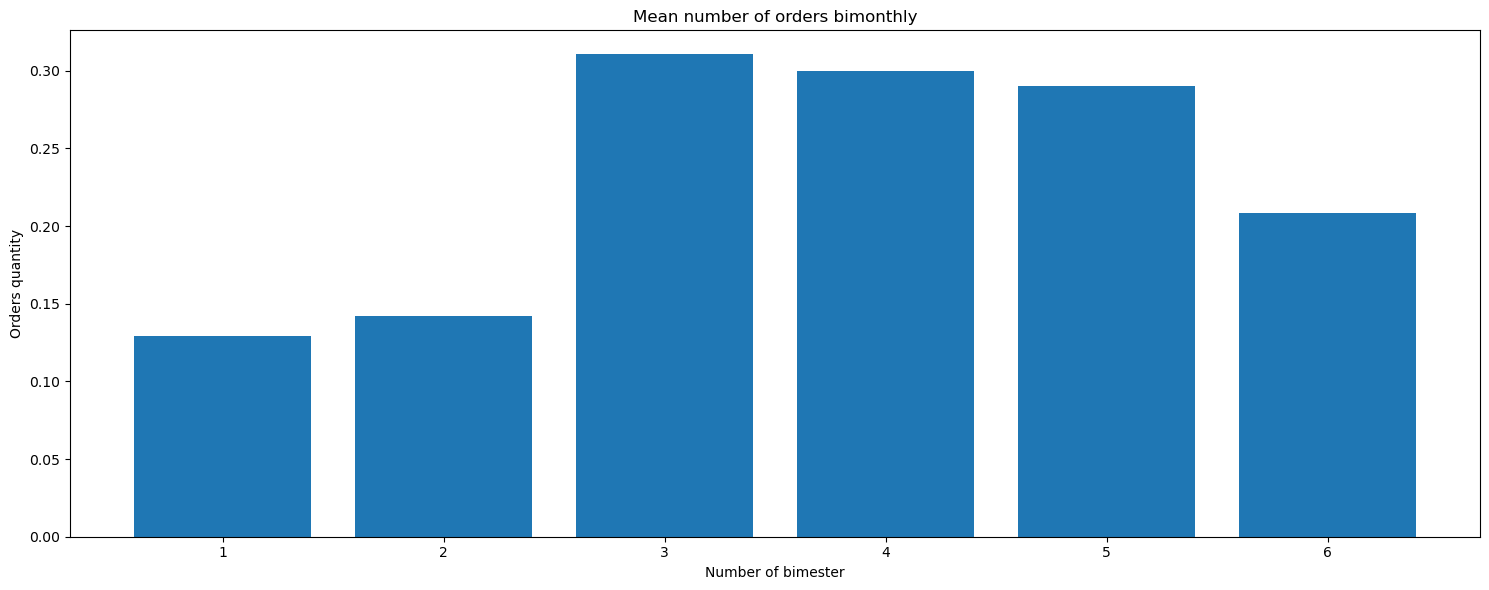

The average quantity of orders made by customers in bimonthly periods is about 0.0


In [23]:
# Definición de intervalos de tiempo para análisis de pedidos bimestrales
range_minimum_end = orders['Buy_Ts'].min().replace(day=1).normalize()
range_maximum_end = orders['Buy_Ts'].max().replace(day=1).normalize()
time_intervals = pd.date_range(
    start=range_minimum_end, 
    end=range_maximum_end, 
    freq='2MS'  # 2MS = cada 2 meses, empezando el primer día
)

# Estructuración de dataframe de intervalos bimestrales
interval_starts = time_intervals[:-1]  # Todos excepto el último
interval_ends = time_intervals[1:] - pd.Timedelta(days=1)  # Siguiente período - 1 día
df_intervals = pd.DataFrame({
    'interval_minimum_end': interval_starts,
    'interval_maximum_end': interval_ends,
    'interval_number': range(1, len(interval_starts) + 1)
})

# Ajuste de horas de los extremos de los intervalos para 00:00:00 y 23:59:59
df_intervals['interval_minimum_end'] = df_intervals['interval_minimum_end'].apply(
    lambda x: x.replace(hour=0, minute=0, second=0))
df_intervals['interval_maximum_end'] = df_intervals['interval_maximum_end'].apply(
    lambda x: x.replace(hour=23, minute=59, second=59))

# Definir el número de bimestre al que pertenece cada orden
bins = list(df_intervals['interval_minimum_end']) + [df_intervals['interval_maximum_end'].iloc[-1]]# Crear los bins para pd.cut (necesitamos incluir todos los límites)
# Asignar cada orden a su intervalo
orders['bimester_number'] = pd.cut(
orders['Buy_Ts'], 
bins=bins, 
labels=df_intervals['interval_number'],
include_lowest=True
)

# Agrupación de ordenes por número de bimestre
bimester_orders = orders.groupby(['bimester_number','Uid'], observed=False).agg({'Buy_Ts':'count'}).reset_index()
customer_bimonthly_order = bimester_orders.groupby('bimester_number', observed=False).agg({'Buy_Ts':'mean'}).reset_index()
customer_bimonthly_orders_mean = np.floor(customer_bimonthly_order['Buy_Ts'].mean())

#Generación de gráfico de no. de ordenes promedio de clientes por bimestre

plt.figure(figsize=(15, 6))
plt.bar(customer_bimonthly_order['bimester_number'], customer_bimonthly_order['Buy_Ts'])
plt.title('Mean number of orders bimonthly')
plt.xlabel('Number of bimester')
plt.ylabel('Orders quantity')
plt.tight_layout()
plt.show()

print("The average quantity of orders made by customers in bimonthly periods is about",customer_bimonthly_orders_mean)

### 📈 Hallazgos Clave:

**Tendencia general**:
- La mayoría de clientes no hacen múltiples compras en el mismo bimestre
- El comportamiento de compra es muy esporádico
- Esto es consistente con tu análisis previo de retención (menos del 10%)

Con base en los resultados percibidos mediante un análisis bimestral, se intentará con una segunda y tercera propuesta con periodos de tiempo mensual y semestral.

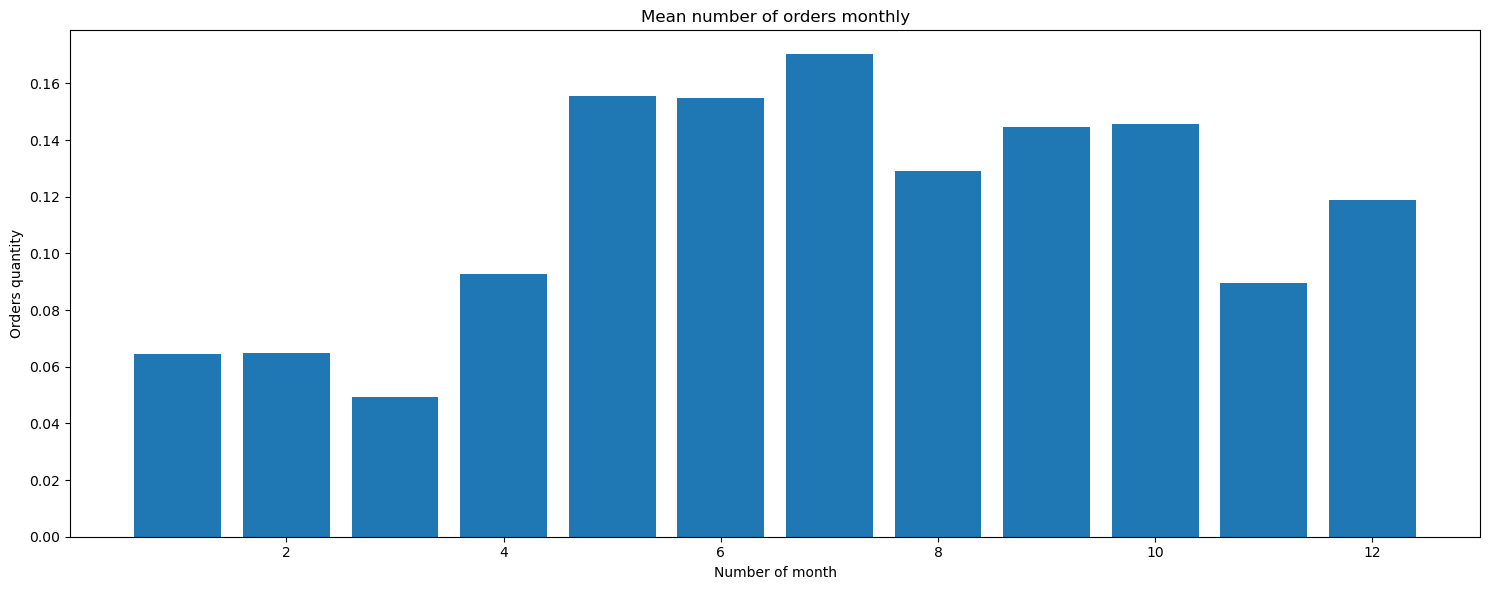

The average quantity of orders made by customers in monthly periods is about 0.0


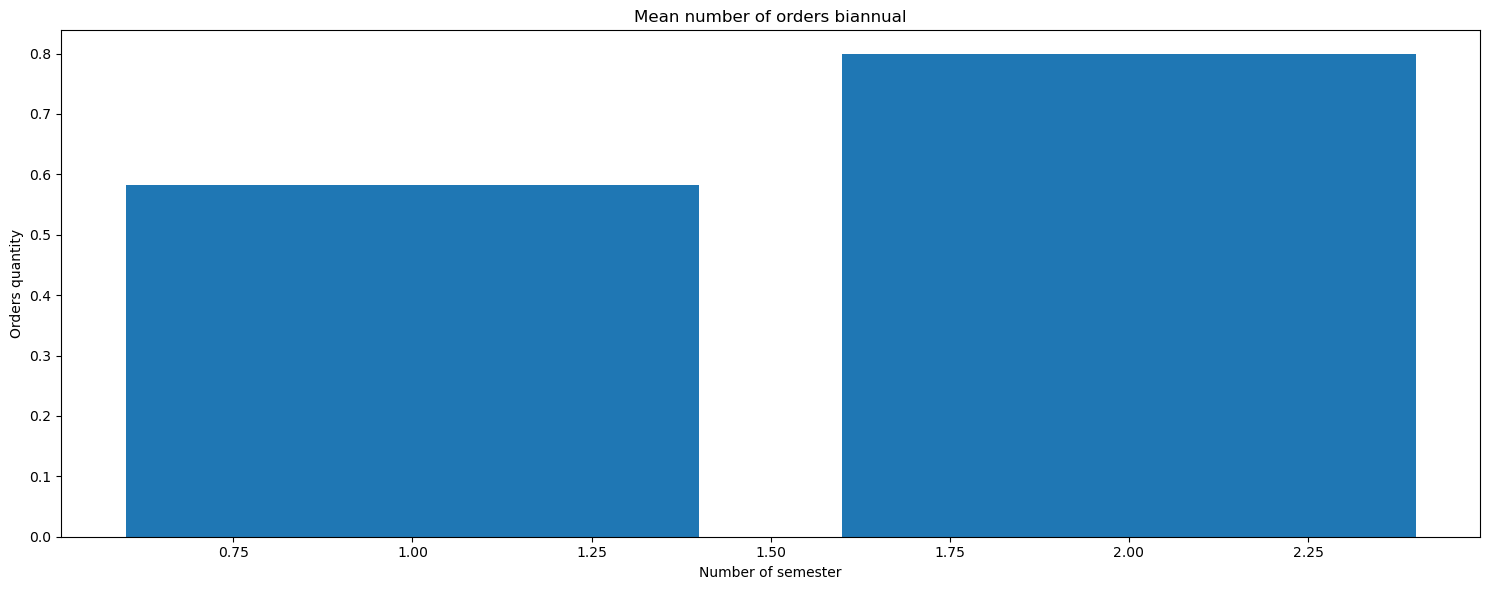

The average quantity of orders made by customers in biannual periods is about 0.0


In [24]:
# Definición de intervalos de tiempo para análisis de pedidos mensuales y semestrales
time_intervals_1M = pd.date_range(
    start=range_minimum_end, 
    end=range_maximum_end, 
    freq='1MS'  # 1MS = cada 1 mes, empezando el primer día
)
time_intervals_6M = pd.date_range(
    start=range_minimum_end, 
    end=range_maximum_end, 
    freq='6MS'  # 6MS = cada 6 meses, empezando el primer día
)

# Estructuración de dataframe de intervalos mensuales y semestrales
interval_starts_1M = time_intervals_1M[:-1]  # Todos excepto el último
interval_ends_1M = time_intervals_1M[1:] - pd.Timedelta(days=1)  # Siguiente período - 1 día
df_intervals_1M = pd.DataFrame({
    'interval_minimum_end': interval_starts_1M,
    'interval_maximum_end': interval_ends_1M,
    'interval_number': range(1, len(interval_starts_1M) + 1)
})
interval_starts_6M = time_intervals_6M[:-1]  # Todos excepto el último
interval_ends_6M = time_intervals_6M[1:] - pd.Timedelta(days=1)  # Siguiente período - 1 día
df_intervals_6M = pd.DataFrame({
    'interval_minimum_end': interval_starts_6M,
    'interval_maximum_end': interval_ends_6M,
    'interval_number': range(1, len(interval_starts_6M) + 1)
})

# Ajuste de horas de los extremos de los intervalos para 00:00:00 y 23:59:59
df_intervals_1M['interval_minimum_end'] = df_intervals_1M['interval_minimum_end'].apply(
    lambda x: x.replace(hour=0, minute=0, second=0))
df_intervals_1M['interval_maximum_end'] = df_intervals_1M['interval_maximum_end'].apply(
    lambda x: x.replace(hour=23, minute=59, second=59))
df_intervals_6M['interval_minimum_end'] = df_intervals_6M['interval_minimum_end'].apply(
    lambda x: x.replace(hour=0, minute=0, second=0))
df_intervals_6M['interval_maximum_end'] = df_intervals_6M['interval_maximum_end'].apply(
    lambda x: x.replace(hour=23, minute=59, second=59))

# Definir el número de mes o semestre al que pertenece cada orden
bins_1M = list(df_intervals_1M['interval_minimum_end']) + [df_intervals_1M['interval_maximum_end'].iloc[-1]]# Crear los bins para pd.cut (necesitamos incluir todos los límites)
# Asignar cada orden a su intervalo
orders['month_number'] = pd.cut(
orders['Buy_Ts'], 
bins=bins_1M, 
labels=df_intervals_1M['interval_number'],
include_lowest=True
)
bins_6M = list(df_intervals_6M['interval_minimum_end']) + [df_intervals_6M['interval_maximum_end'].iloc[-1]]# Crear los bins para pd.cut (necesitamos incluir todos los límites)
# Asignar cada orden a su intervalo
orders['semester_number'] = pd.cut(
orders['Buy_Ts'], 
bins=bins_6M, 
labels=df_intervals_6M['interval_number'],
include_lowest=True
)

# Agrupación de ordenes por número de mes o semestre
month_orders = orders.groupby(['month_number','Uid'], observed=False).agg({'Buy_Ts':'count'}).reset_index()
customer_monthly_order = month_orders.groupby('month_number', observed=False).agg({'Buy_Ts':'mean'}).reset_index()
customer_monthly_orders_mean = np.floor(customer_monthly_order['Buy_Ts'].mean())
semester_orders = orders.groupby(['semester_number','Uid'], observed=False).agg({'Buy_Ts':'count'}).reset_index()
customer_biannual_order = semester_orders.groupby('semester_number',observed=False).agg({'Buy_Ts':'mean'}).reset_index()
customer_biannual_orders_mean = np.floor(customer_biannual_order['Buy_Ts'].mean())

#Generación de gráfico de no. de ordenes promedio de clientes por mes y semestre
plt.figure(figsize=(15, 6))
plt.bar(customer_monthly_order['month_number'], customer_monthly_order['Buy_Ts'])
plt.title('Mean number of orders monthly')
plt.xlabel('Number of month')
plt.ylabel('Orders quantity')
plt.tight_layout()
plt.show()

print("The average quantity of orders made by customers in monthly periods is about",customer_monthly_orders_mean)

plt.figure(figsize=(15, 6))
plt.bar(customer_biannual_order['semester_number'], customer_biannual_order['Buy_Ts'])
plt.title('Mean number of orders biannual')
plt.xlabel('Number of semester')
plt.ylabel('Orders quantity')
plt.tight_layout()
plt.show()

print("The average quantity of orders made by customers in biannual periods is about",customer_biannual_orders_mean)

### 📈 Hallazgos Clave:

**Tendencia general**:
- La mayoría de clientes no hacen múltiples compras en el mismo mes o semestre
- El comportamiento de compra es muy esporádico
- Esto es consistente con tu análisis previo de retención (menos del 10%)

Debido a estos resultados percibidos, se prescindirá de realizar una comparación por fuentes de anuncios o de dispositivos, ya que se puede entender que no se obtendrá gran información de utilidad, considerando que desde un análisis general, se nota que la mayoría de clientes no hacen múltiples compras en el mismo mes o semestre; por ende, el comportamiento de compra es muy esporádico


### ¿Cuál es el tamaño promedio de compra?

#### Análisis general de tamaño promedio de orden

In [25]:
# Promedio general
print("El promedio general de tamaño de compra es de",orders['Revenue'].mean())

El promedio general de tamaño de compra es de 4.999646930477041


#### Análisis comparativo de tamaño promedio de orden por fuente de anuncios

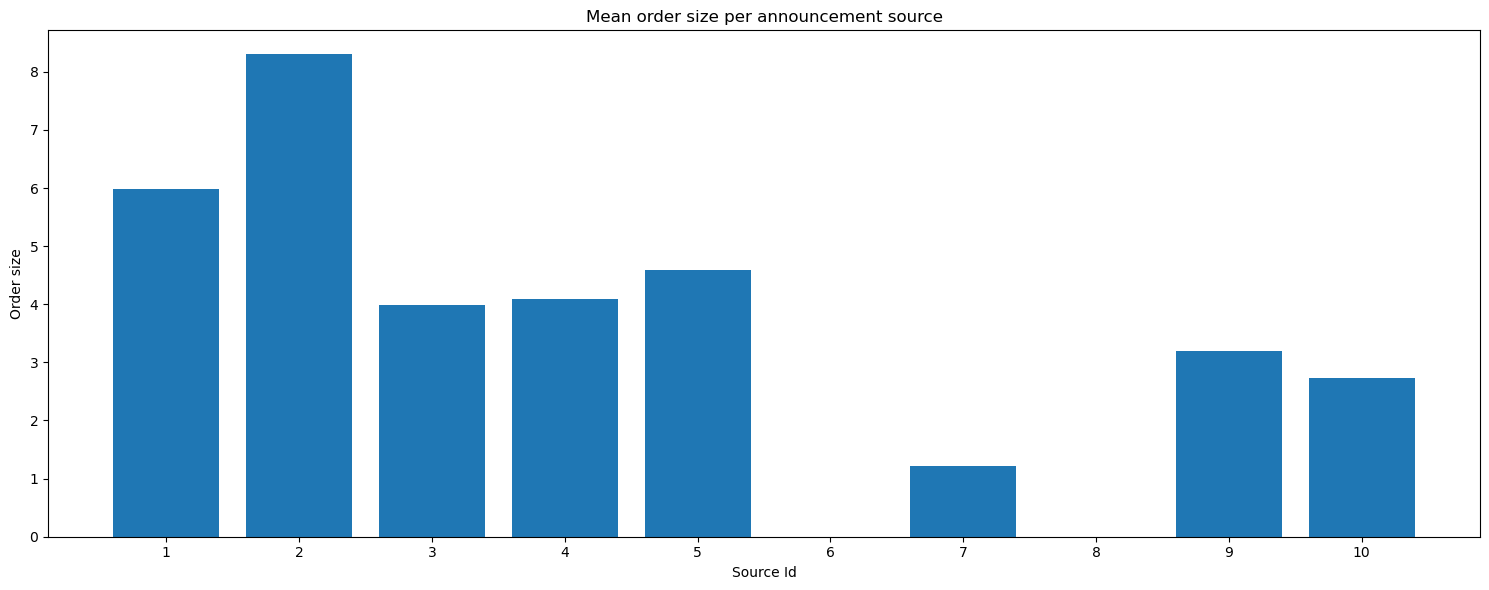

In [26]:
# Uso de función para obtener dataframe orders con source
orders_with_source = get_latest_source_before_purchase(orders, visits)

# Agrupación de órdenes por source y obtención de promedio
revenues_per_source = orders_with_source.groupby('Source_Id').agg({'Revenue':'mean'}).reset_index()

# Generación de gráfico de barras para tamaño promedio de orden con base en fuente de anuncios
plt.figure(figsize=(15, 6))
plt.bar(revenues_per_source['Source_Id'], revenues_per_source['Revenue'])
plt.title('Mean order size per announcement source')
plt.xlabel('Source Id')
plt.xticks([1,2,3,4,5,6,7,8,9,10])
plt.ylabel('Order size')
plt.tight_layout()
plt.show()

#### Análisis comparativo de tamaño promedio de orden por dispositivo

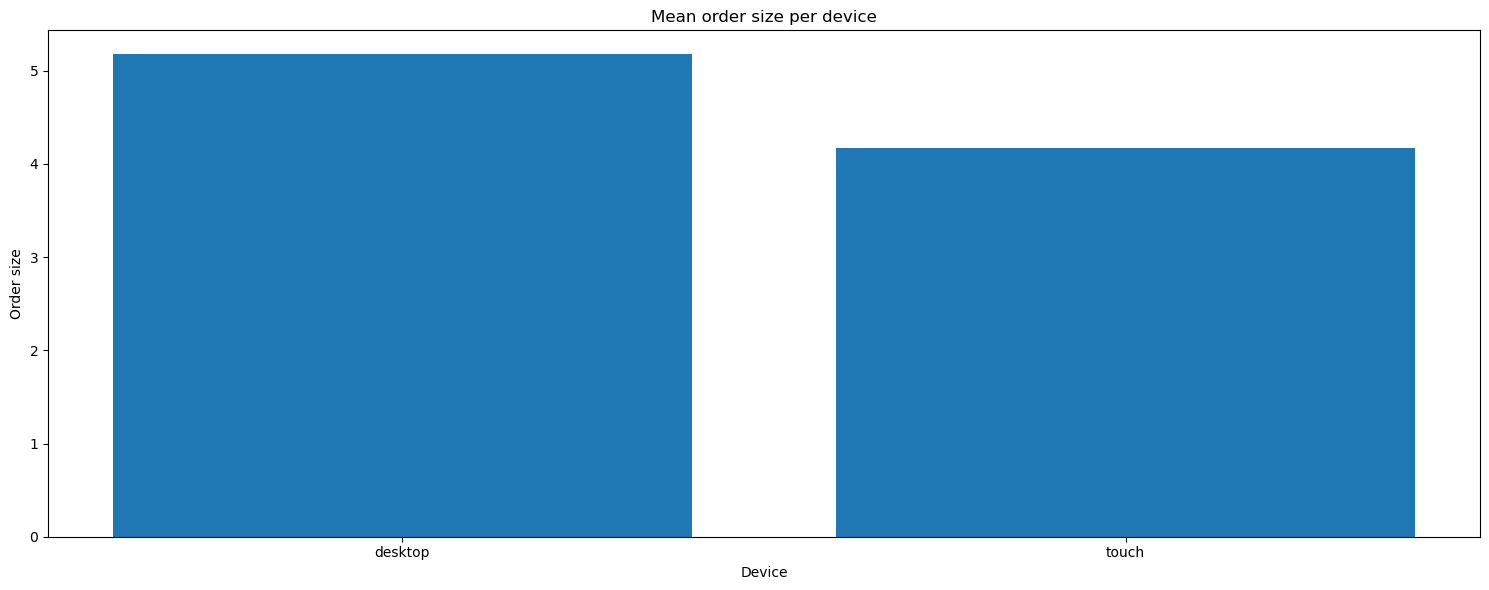

In [27]:
# Uso de función para obtener dataframe orders con source
orders_with_device = get_latest_device_before_purchase(orders_with_source, visits)

# Agrupación de órdenes por source y obtención de promedio
revenues_per_device = orders_with_device.groupby('Device').agg({'Revenue':'mean'}).reset_index()

# Generación de gráfico de barras para tamaño promedio de orden con base en fuente de anuncios
plt.figure(figsize=(15, 6))
plt.bar(revenues_per_device['Device'], revenues_per_device['Revenue'])
plt.title('Mean order size per device')
plt.xlabel('Device')
plt.ylabel('Order size')
plt.tight_layout()
plt.show()

#### Análisis evolutivo del tamaño promedio de orden con el tiempo 

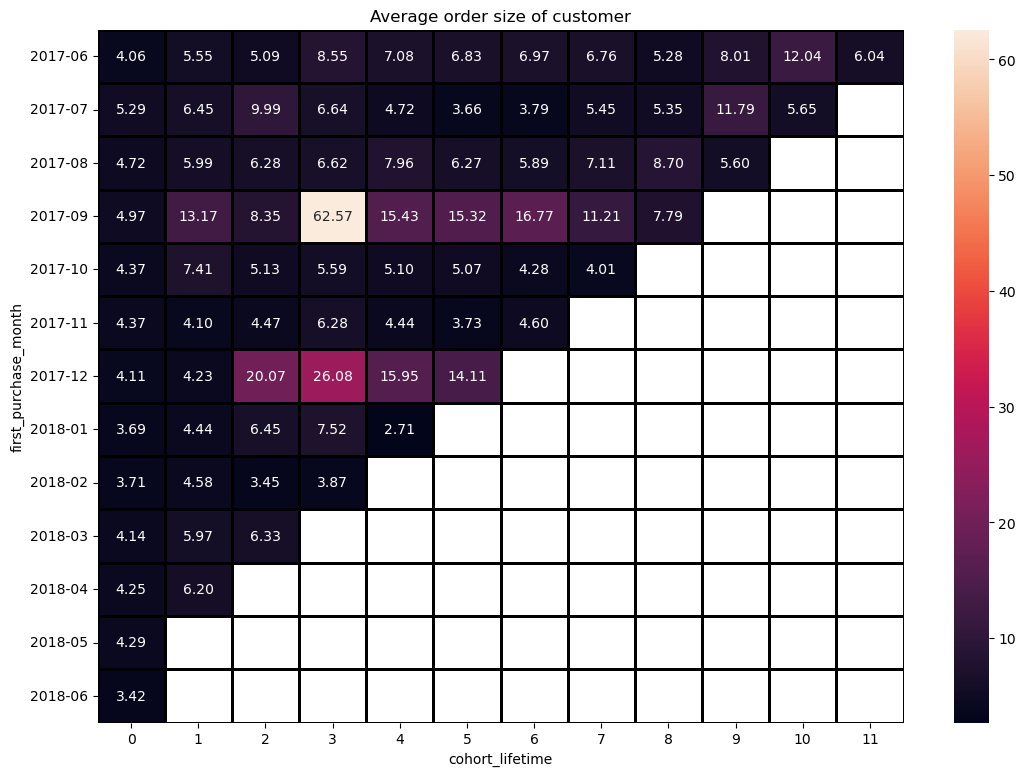

In [28]:
# Generación de cohortes de órdenes por mes de compra
orders['first_purchase_month'] = pd.DatetimeIndex(orders['first_purchase_date']).to_period('M').to_timestamp()
orders['purchase_month'] = pd.DatetimeIndex(orders['Buy_Ts']).to_period('M').to_timestamp()
orders_cohorts = orders.groupby(['first_purchase_month','purchase_month']).agg({'Revenue':'mean'}).reset_index()
orders_cohorts['cohort_lifetime'] = (orders_cohorts['purchase_month'] - orders_cohorts['first_purchase_month'])
orders_cohorts['cohort_lifetime'] = orders_cohorts['cohort_lifetime'] / np.timedelta64(30, 'D')
orders_cohorts['cohort_lifetime'] = orders_cohorts['cohort_lifetime'].round().astype('int')

# Generación de tabla pivot
orders_size_lifetime_pivot = orders_cohorts.pivot_table(
    index='first_purchase_month',
    columns='cohort_lifetime',
    values='Revenue',
    aggfunc='sum'
)

# Gráfico de calor 
plt.figure(figsize=(13,9))
plt.title('Average order size of customer')
sns.heatmap(
    orders_size_lifetime_pivot,
    annot=True,
    fmt='.2f',
    linewidths=1,
    linecolor='black',
    yticklabels=[date.strftime('%Y-%m') for date in orders_size_lifetime_pivot.index]
)
plt.show()


### 📈 Hallazgos Clave:

**Tendencia general**:
- Hallazgo principal:
 El tamaño promedio de compra es de 5.00, lo que indica:
    - Las entradas tienen precios relativamente bajos y accesibles
    - El modelo de negocio se basa en volumen más que en transacciones de alto valor
    - Es consistente con un mercado de entretenimiento masivo
- Diferenciación significativa entre fuentes:
    - Fuentes premium (1, 2, 6): Generan compras de mayor valor (~6-7)
    - Fuentes masivas (3, 4, 5): Compras de menor valor (~4-5)
    - Fuentes especializadas (7, 9, 10): Valores intermedios
- Análisis Comparativo por Dispositivos. Comportamiento diferenciado:
    - Desktop: Mayor tamaño promedio de compra
    - Touch/Mobile: Menor tamaño promedio de compra
    Posibles explicaciones:
    - Los usuarios de desktop tienen más tiempo para explorar opciones premium
    - La experiencia móvil puede favorecer compras rápidas de menor valor

### ¿Cuánto dinero traen? (LTV)

#### Análisis general de LTV

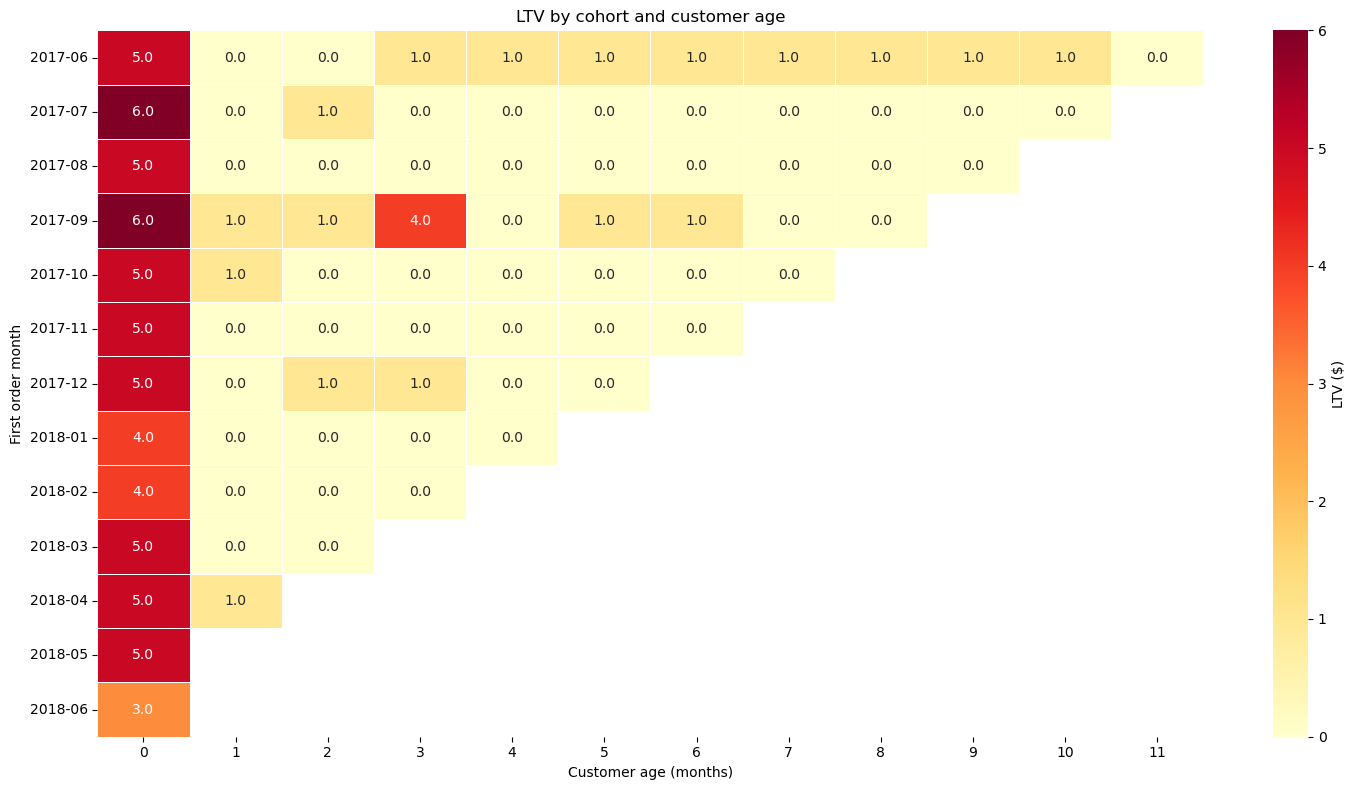

In [29]:
# Definición de cohortes para dataframe orders
orders_cohorts = orders.groupby(['first_purchase_month', 'purchase_month']).agg({'Revenue': 'sum'}).reset_index()

# Definición del tamaño de cohortes
first_orders = orders.groupby('Uid').agg({'purchase_month': 'min'}).reset_index()
first_orders.columns = ['Uid', 'first_purchase_month']
cohort_sizes = first_orders.groupby('first_purchase_month').agg({'Uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_purchase_month', 'n_buyers']

# Definición de reporte
report = pd.merge(cohort_sizes, orders_cohorts, on='first_purchase_month')

# Asumiendo que el margen de beneficio es del 100%, se calculan los beneficios brutos por las ordenes
margin_rate = 1
report['gp'] = report['Revenue'] * margin_rate
report['ltv'] = report['gp'] / report['n_buyers']
report['age'] = (report['purchase_month'] - report['first_purchase_month']) / np.timedelta64(30, 'D')
report['age'] = report['age'].round().astype('int')

# Generación de tabla pivote de los cohortes
result = report.pivot_table(
    index='first_purchase_month',
    columns='age',
    values='ltv',
    aggfunc='mean'
).round()

# Generar mapa de calor 
plt.figure(figsize=(15, 8))
sns.heatmap(
    result, 
    annot=True, 
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'LTV ($)'},
    yticklabels=[date.strftime('%Y-%m') for date in result.index]
)
plt.title('LTV by cohort and customer age')
plt.xlabel('Customer age (months)')
plt.ylabel('First order month')
plt.tight_layout()
plt.show()

#### Análisis comparativo entre fuentes de anuncios del LTV

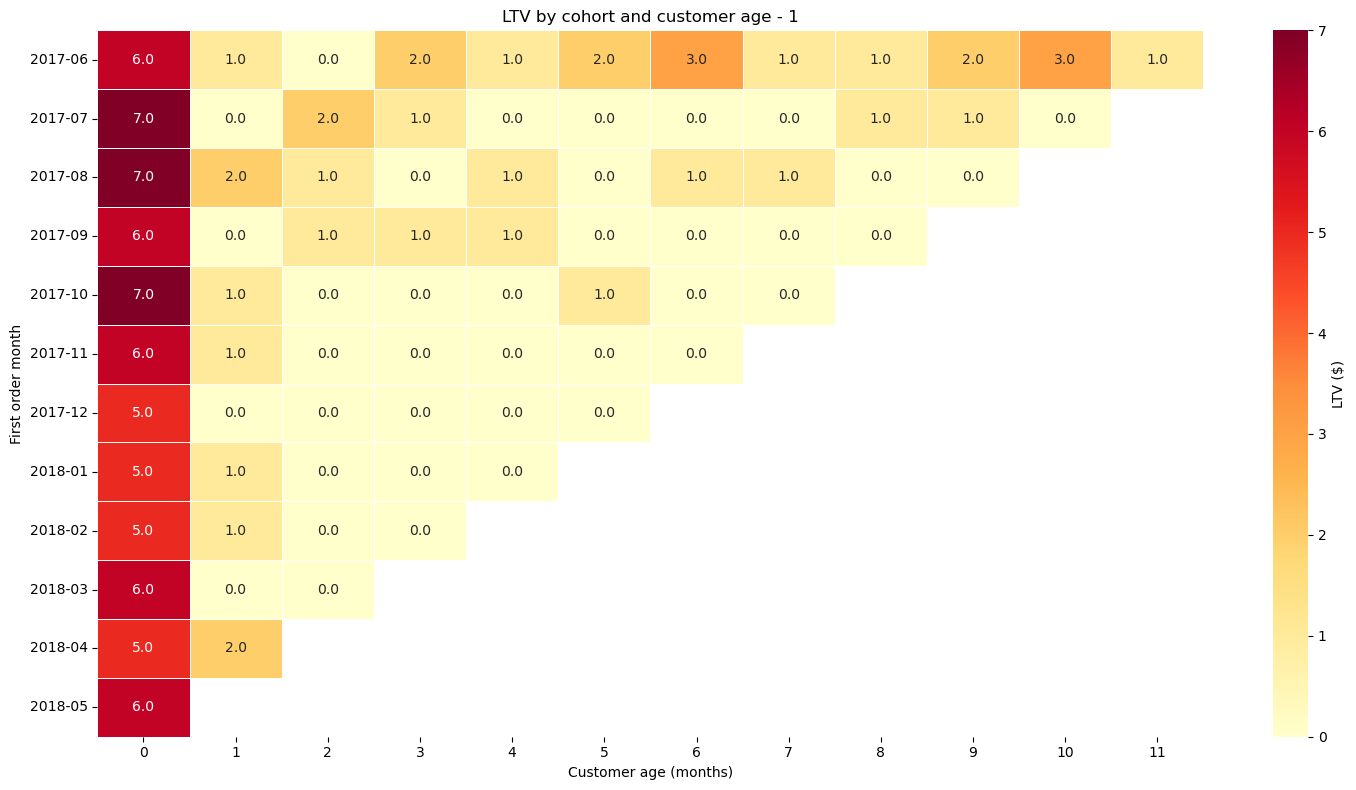


--- LTV stadistics for 1 ---
Average LTV: $1.12
Maximum LTV: $7.00
Minimum LTV: $0.00
--------------------------------------------------


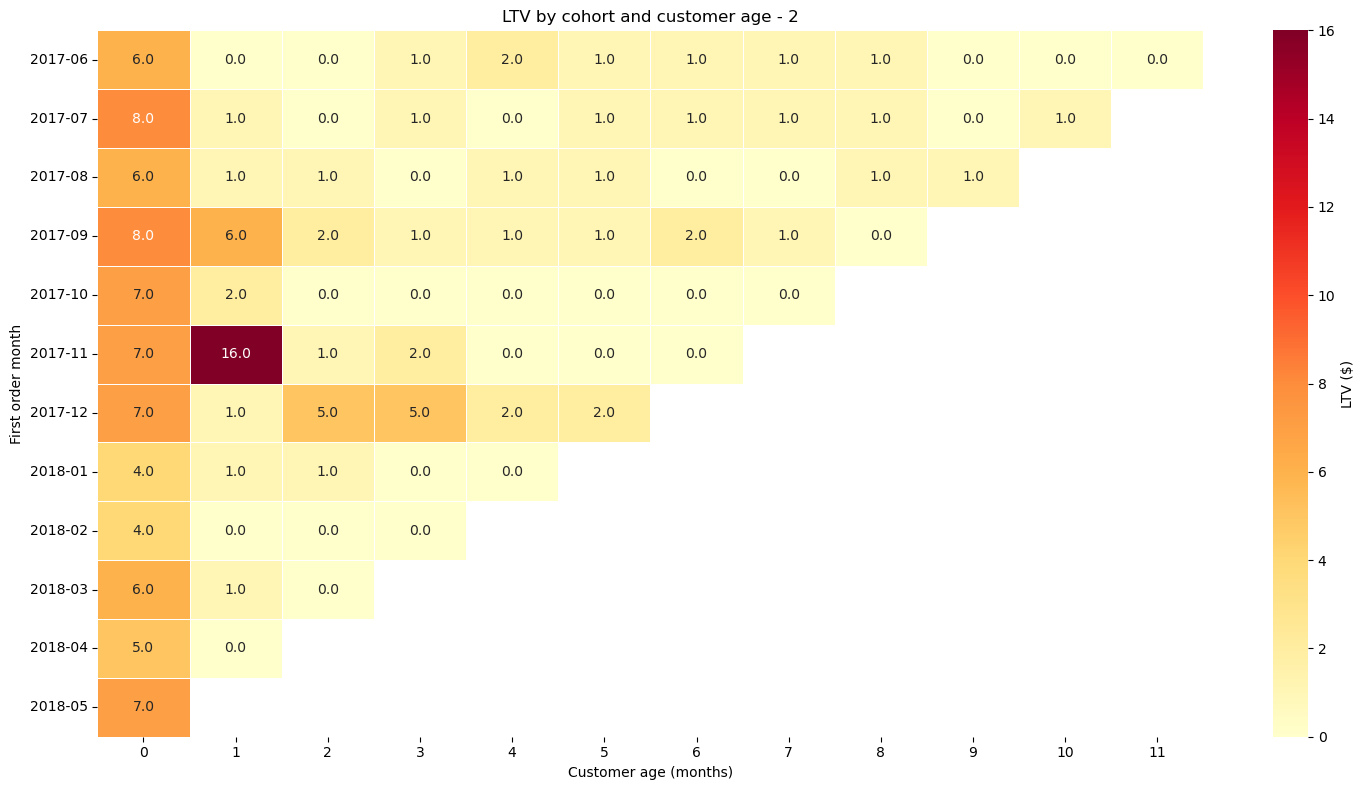


--- LTV stadistics for 2 ---
Average LTV: $1.29
Maximum LTV: $16.00
Minimum LTV: $0.00
--------------------------------------------------


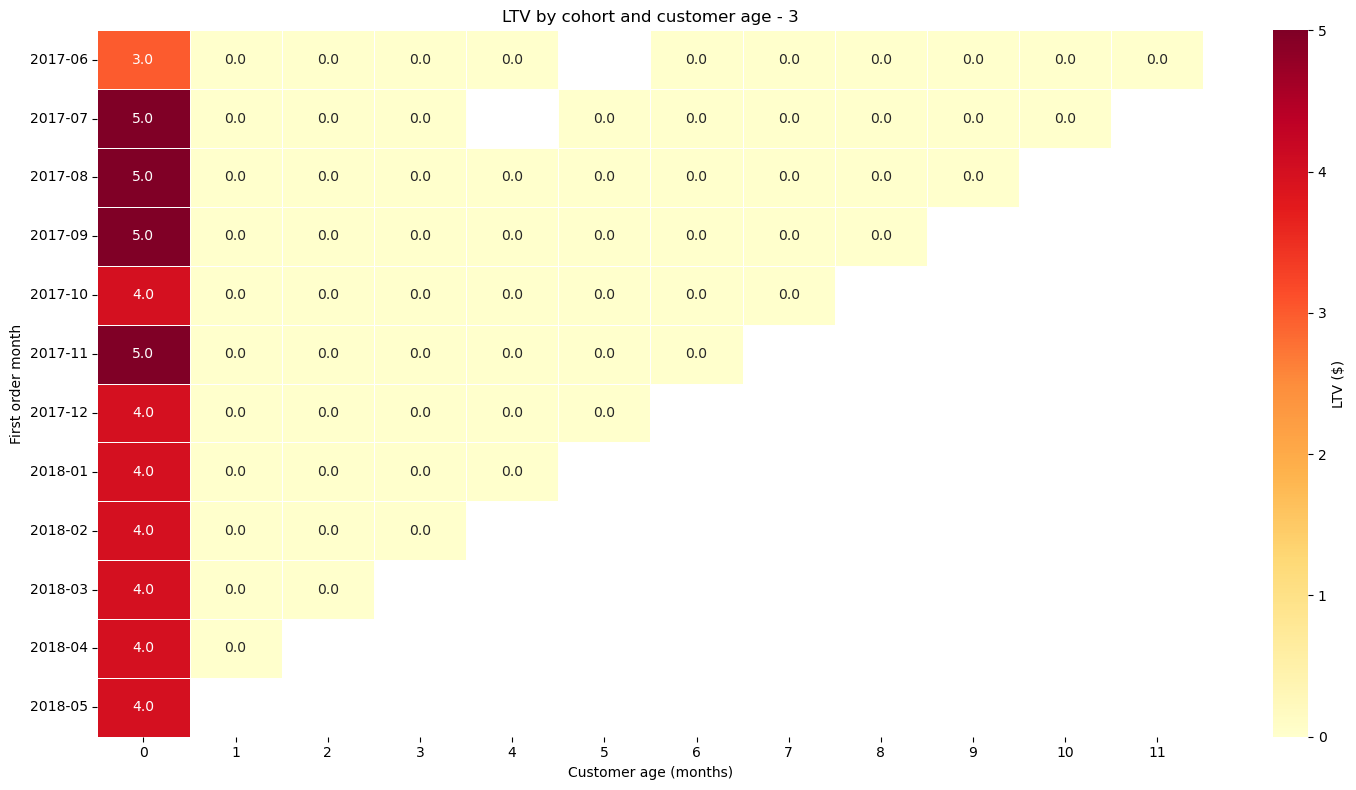


--- LTV stadistics for 3 ---
Average LTV: $0.35
Maximum LTV: $5.00
Minimum LTV: $0.00
--------------------------------------------------


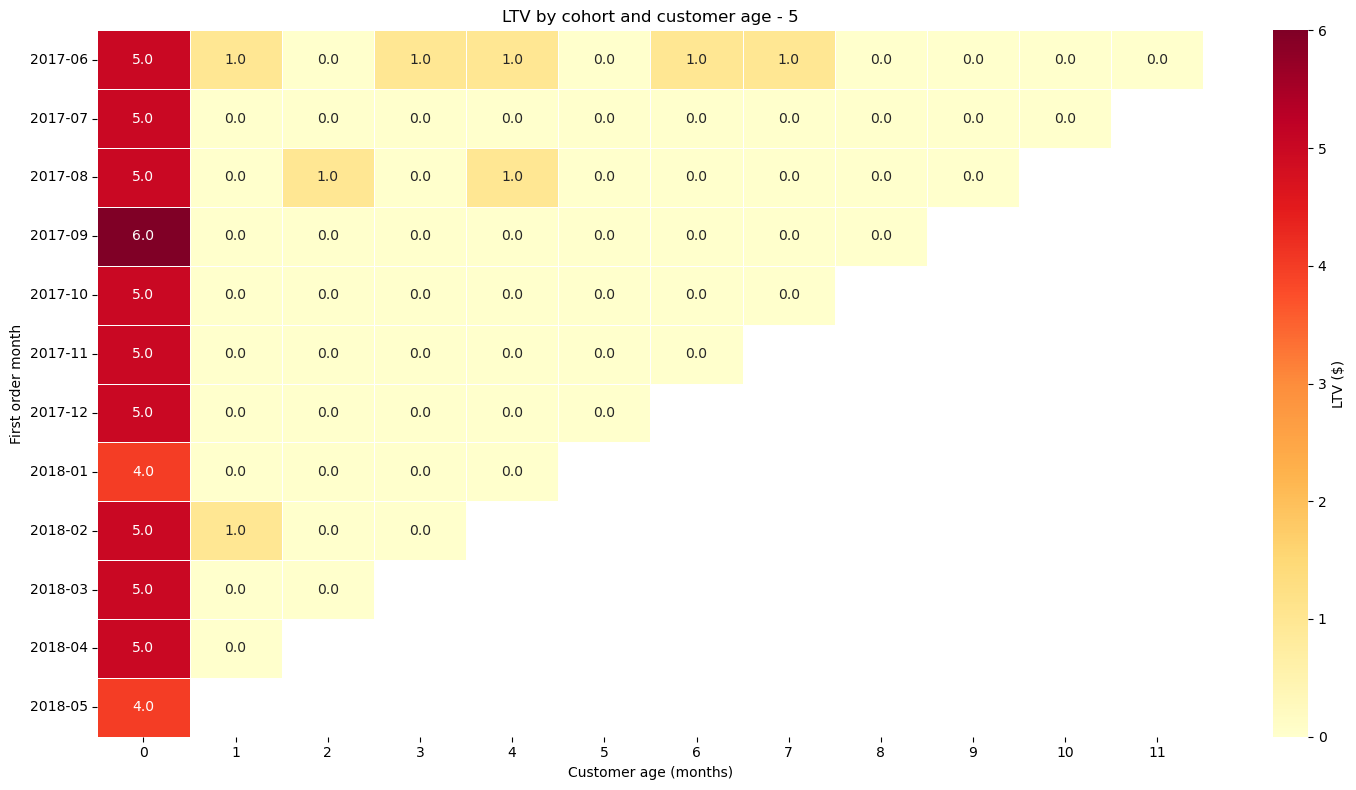


--- LTV stadistics for 5 ---
Average LTV: $0.49
Maximum LTV: $6.00
Minimum LTV: $0.00
--------------------------------------------------


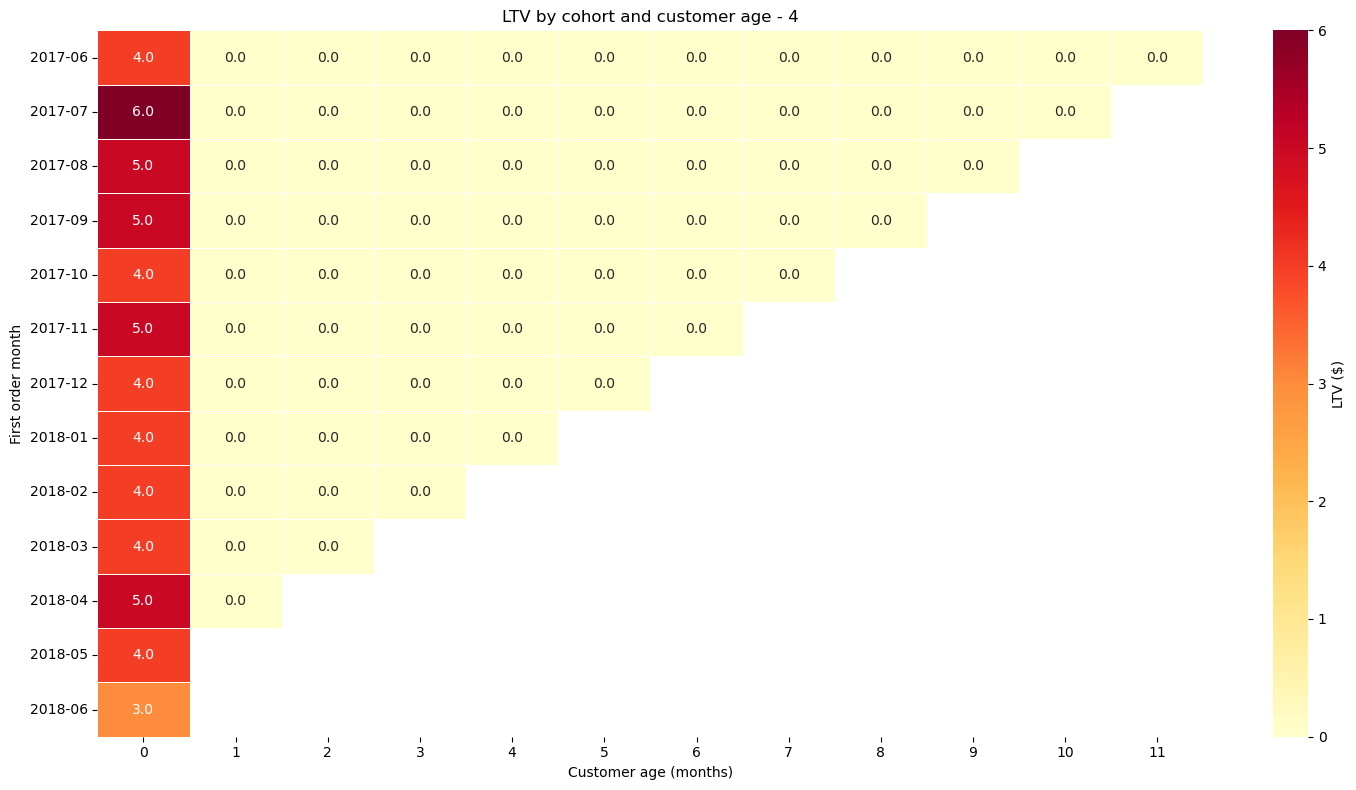


--- LTV stadistics for 4 ---
Average LTV: $0.37
Maximum LTV: $6.00
Minimum LTV: $0.00
--------------------------------------------------


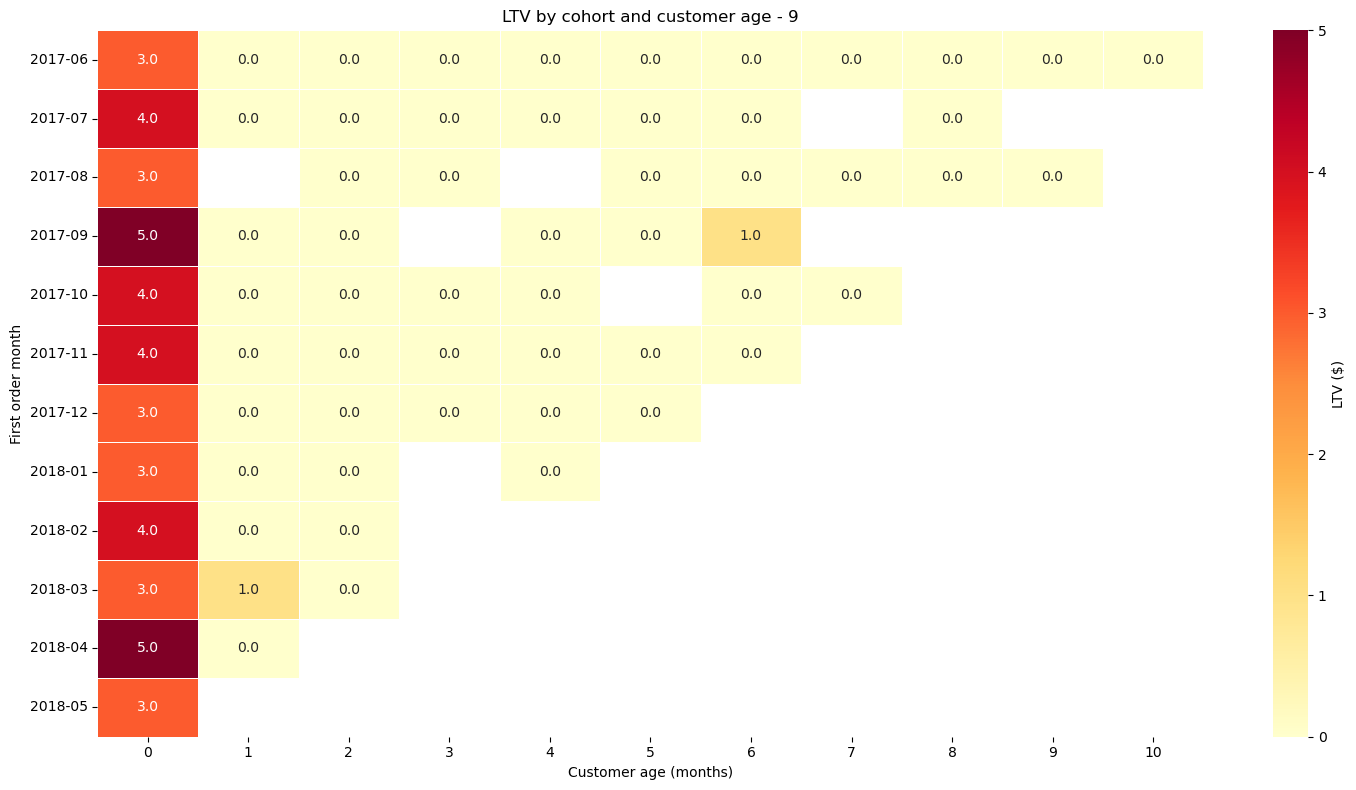


--- LTV stadistics for 9 ---
Average LTV: $0.36
Maximum LTV: $5.00
Minimum LTV: $0.00
--------------------------------------------------


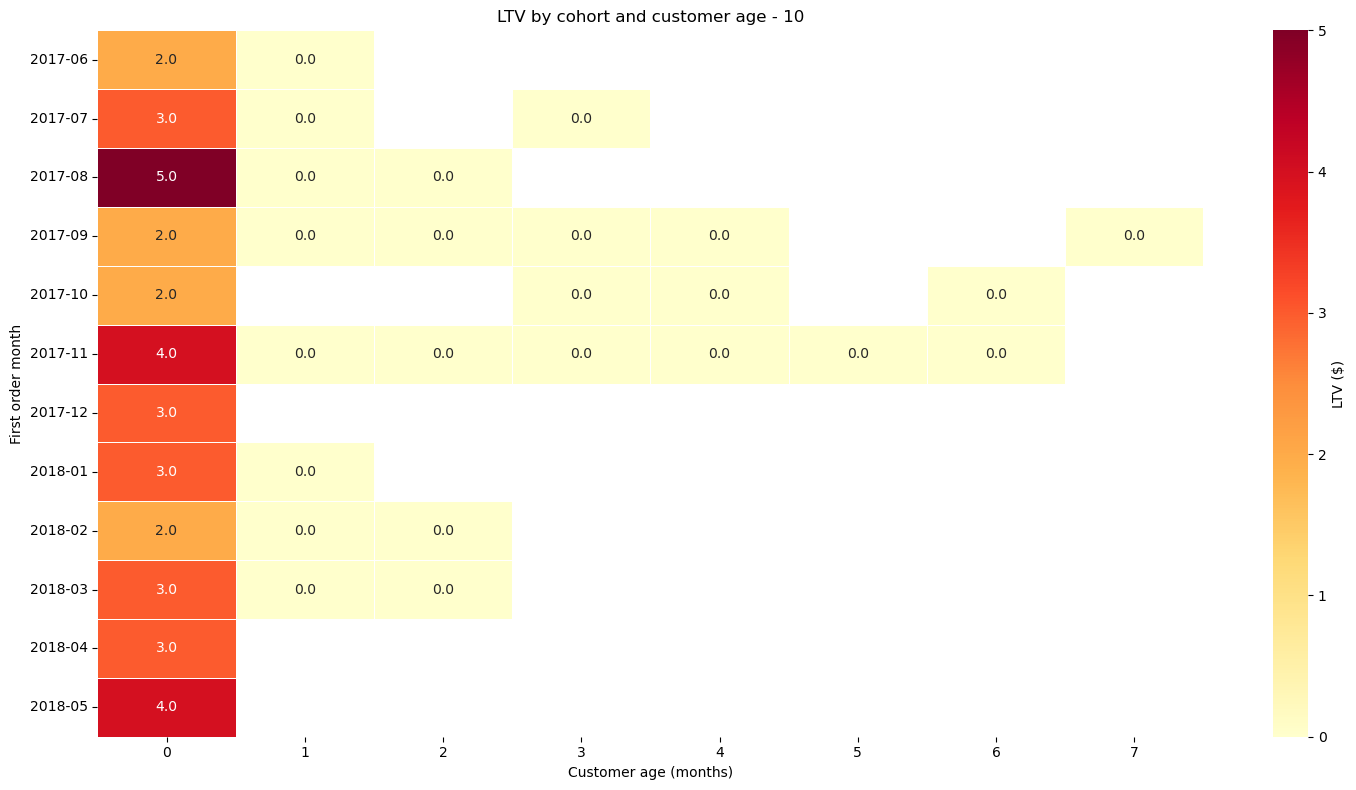


--- LTV stadistics for 10 ---
Average LTV: $0.38
Maximum LTV: $5.00
Minimum LTV: $0.00
--------------------------------------------------


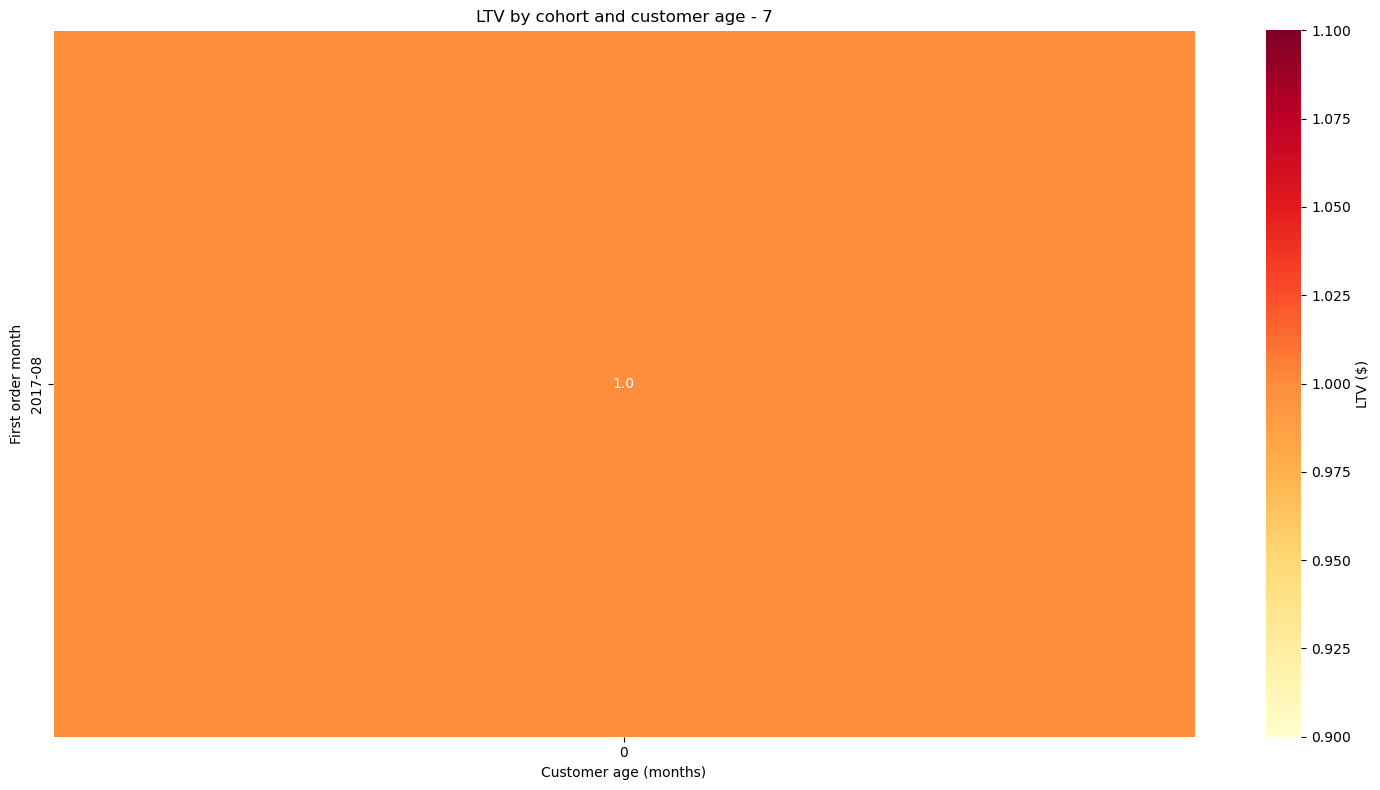


--- LTV stadistics for 7 ---
Average LTV: $1.00
Maximum LTV: $1.00
Minimum LTV: $1.00
--------------------------------------------------


In [30]:
# Función de procesamiento de análisis del LTV en slices de datos
def process_ltv_analysis(orders_dict, margin_rate=1.0):
    """
    Procesa análisis completo de LTV para un diccionario de DataFrames de órdenes
    
    Args:
        orders_dict: Diccionario donde las keys son identificadores y los values son DataFrames de órdenes
        margin_rate: Tasa de margen de beneficio (por defecto 1.0 = 100%)
    
    Returns:
        dict: Diccionario con los mismos keys pero con DataFrames procesados y tablas pivot de LTV
    """
    processed_dict = {}
    
    for key, orders_df in orders_dict.items():
        # Crear copia para no modificar el original
        df_copy = orders_df.copy()
        
        # 1. Definición de cohortes para dataframe orders
        df_copy['first_purchase_month'] = pd.DatetimeIndex(df_copy['first_purchase_date']).to_period('M').to_timestamp()
        df_copy['purchase_month'] = pd.DatetimeIndex(df_copy['Buy_Ts']).to_period('M').to_timestamp()
        orders_cohorts = df_copy.groupby(['first_purchase_month', 'purchase_month']).agg({'Revenue': 'sum'}).reset_index()
        
        # 2. Definición del tamaño de cohortes
        first_orders = df_copy.groupby('Uid').agg({'purchase_month': 'min'}).reset_index()
        first_orders.columns = ['Uid', 'first_purchase_month']
        cohort_sizes = first_orders.groupby('first_purchase_month').agg({'Uid': 'nunique'}).reset_index()
        cohort_sizes.columns = ['first_purchase_month', 'n_buyers']
        
        # 3. Definición de reporte
        report = pd.merge(cohort_sizes, orders_cohorts, on='first_purchase_month')
        
        # 4. Considerando el valor definido de margen de beneficio, se calculan los beneficios brutos por las ordenes
        report['gp'] = report['Revenue'] * margin_rate
        report['ltv'] = report['gp'] / report['n_buyers']
        report['age'] = (report['purchase_month'] - report['first_purchase_month']) / np.timedelta64(30, 'D')
        report['age'] = report['age'].round().astype('int')
        
        # 5. Generación de tabla pivote de los cohortes
        ltv_pivot = report.pivot_table(
            index='first_purchase_month',
            columns='age',
            values='ltv',
            aggfunc='mean'
        ).round()
        
        # Guardar tanto el DataFrame procesado como la tabla pivot
        processed_dict[key] = {
            'processed_orders': df_copy,
            'ltv_report': report,
            'ltv_pivot': ltv_pivot
        }
    
    return processed_dict

# Función de generación de mapa de calor del LTV
def create_ltv_heatmaps(ltv_results_dict, title_prefix="LTV"):
    """
    Genera mapas de calor de LTV para cada resultado en el diccionario
    
    Args:
        ltv_results_dict: Diccionario resultado de process_ltv_analysis
        title_prefix: Prefijo para los títulos de los gráficos
    """
    for key, data in ltv_results_dict.items():
        ltv_pivot = data['ltv_pivot']
        
        plt.figure(figsize=(15, 8))
        sns.heatmap(
            ltv_pivot,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'LTV ($)'},
            yticklabels=[date.strftime('%Y-%m') for date in ltv_pivot.index]
        )
        plt.title(f'{title_prefix} by cohort and customer age - {key}')
        plt.xlabel('Customer age (months)')
        plt.ylabel('First order month')
        plt.tight_layout()
        plt.show()
        
        print(f"\n--- LTV stadistics for {key} ---")
        print(f"Average LTV: ${ltv_pivot.mean().mean():.2f}")
        print(f"Maximum LTV: ${ltv_pivot.max().max():.2f}")
        print(f"Minimum LTV: ${ltv_pivot.min().min():.2f}")
        print("-" * 50)


# Uso de funciones para determinación de mapas de calor de LTV por slices de fuentes de anuncios
ltv_slices_sources = process_ltv_analysis(orders_slices_sources, margin_rate=1.0)
create_ltv_heatmaps(ltv_slices_sources, title_prefix="LTV")


#### Análisis comparativo entre dispositivos del LTV

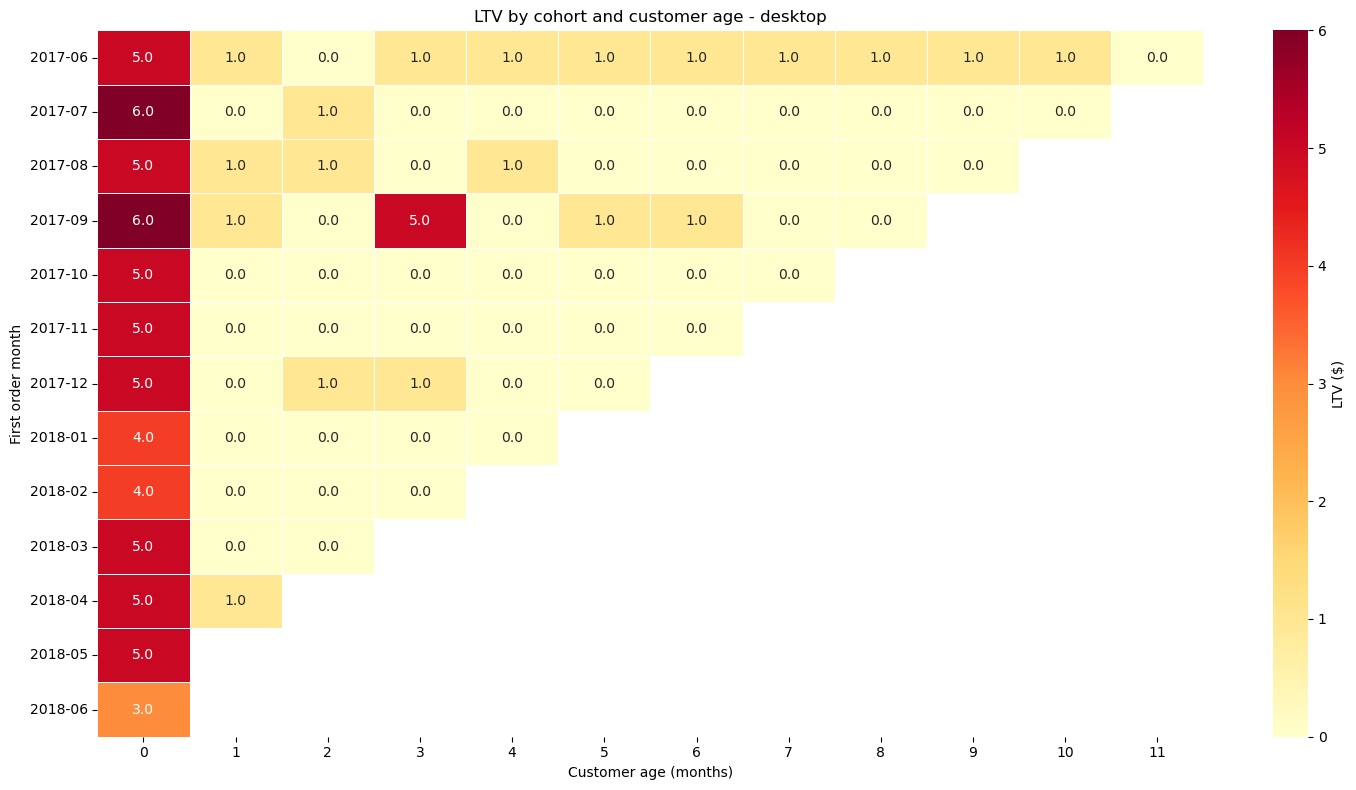


--- LTV stadistics for desktop ---
Average LTV: $0.70
Maximum LTV: $6.00
Minimum LTV: $0.00
--------------------------------------------------


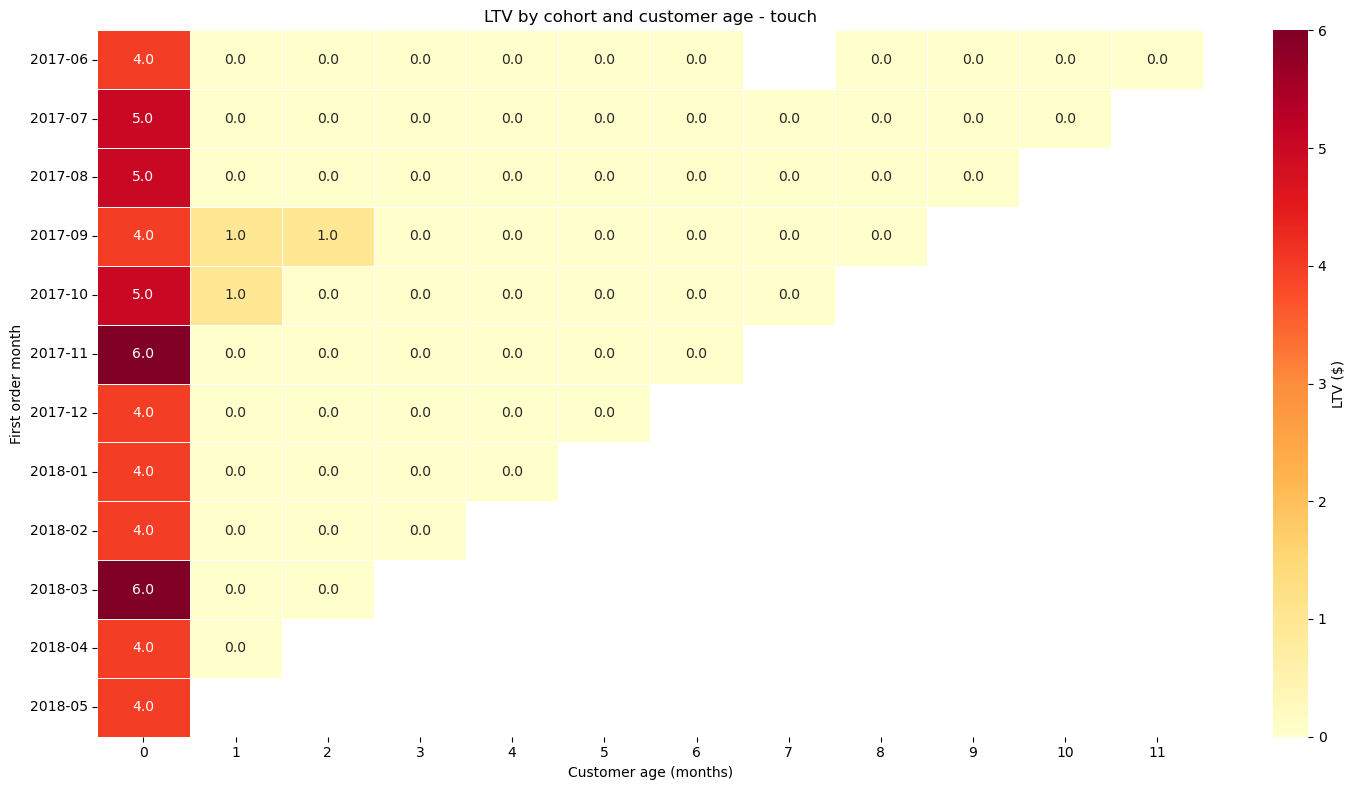


--- LTV stadistics for touch ---
Average LTV: $0.41
Maximum LTV: $6.00
Minimum LTV: $0.00
--------------------------------------------------


In [31]:
# Uso de funciones para determinación de mapas de calor de LTV por slices de dispositivos
ltv_slices_devices = process_ltv_analysis(orders_slices_devices, margin_rate=1.0)
create_ltv_heatmaps(ltv_slices_devices, title_prefix="LTV")

### 📈 Hallazgos Clave:

**Tendencia general**:
Análisis General del LTV
- Comportamiento del Cliente:
    - El LTV promedio general es relativamente bajo, lo que es consistente con el modelo de negocio de venta de entradas.
    - Los clientes muestran un comportamiento de compra esporádico, no recurrente.
    - La mayoría del valor se genera en los primeros meses después de la primera compra

Análisis Comparativo por Fuentes de Anuncios
- Fuentes de Alto Rendimiento:
    - Fuente 2: LTV promedio de 1.29, LTV máximo de 16.00 - La más rentable.
    - Fuente 1: LTV promedio de 1.12, LTV máximo de 7.00 - Segunda mejor performance.
- Fuentes de Rendimiento Medio:
    - Fuentes 5, 4, 10, 9: LTV promedio entre 0.36-0.49. Generan valor pero con menor intensidad.
- Fuentes de Bajo Rendimiento:
    - Fuente 3: LTV promedio de solo 0.35 a pesar de generar alto volumen.
    - Fuente 7 y 6: Datos limitados (LTV de 1.00 pero muy pocos clientes).

Análisis Comparativo por Dispositivos
- Desktop: LTV promedio de 0.70 - 70% superior al móvil
- Touch: LTV promedio de 0.41 - Menor valor por cliente


## 3. Marketing

### ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 

#### Análisis general del gasto total

In [32]:
# Análisis general de gastos de la empresa
total_costs=costs['costs'].sum()
print("El total gastado por la empresa en el periodo de tiempo de los datos fue $",total_costs)

El total gastado por la empresa en el periodo de tiempo de los datos fue $ 329131.62


#### Análisis comparativo entre fuentes de adquisición del gasto total

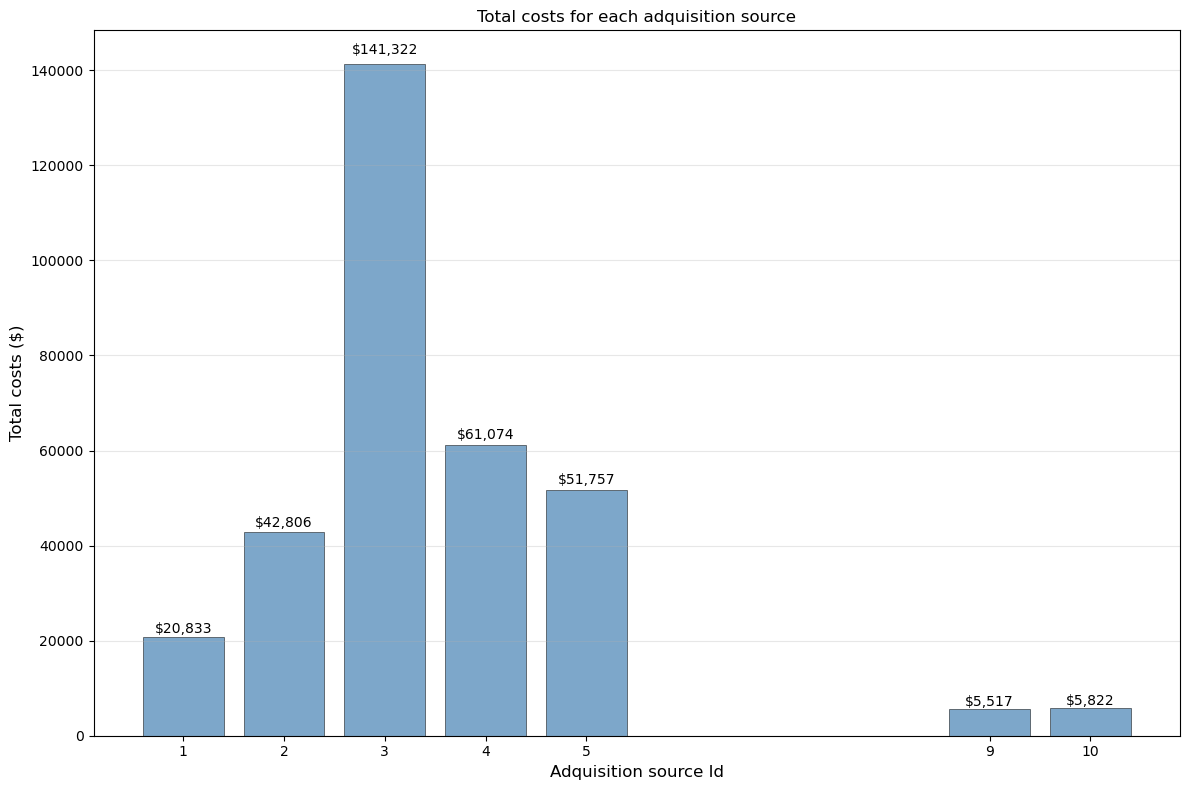

=== COSTS BY SOURCE RESUME ===
TOTAL COST: $329,131.62
Average cost by source: $47,018.80
Most expensive source: Source 3 ($141,321.63)
Less expensive source: Source 9 ($5,517.49)


In [33]:
# Análisis comparativo entre fuente de adquisición de los gastos de la empresa
source_costs=costs.groupby('source_id').agg({'costs':'sum'}).reset_index()

# Generación de gráfico de barras para costos totales generados por fuente de adquisición
plt.figure(figsize=(12, 8))
bars = plt.bar(source_costs['source_id'], source_costs['costs'], 
               color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)

# Personalización del gráfico
plt.title('Total costs for each adquisition source')
plt.xlabel('Adquisition source Id', fontsize=12)
plt.ylabel('Total costs ($)', fontsize=12)

# Configurar las marcas del eje X para mostrar todos los source_id
plt.xticks(source_costs['source_id'])

# Agregar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

# Agregar grilla para mejor lectura
plt.grid(True, alpha=0.3, axis='y')

# Ajustar el layout y mostrar
plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print("=== COSTS BY SOURCE RESUME ===")
print(f"TOTAL COST: ${source_costs['costs'].sum():,.2f}")
print(f"Average cost by source: ${source_costs['costs'].mean():,.2f}")
print(f"Most expensive source: Source {source_costs.loc[source_costs['costs'].idxmax(), 'source_id']} (${source_costs['costs'].max():,.2f})")
print(f"Less expensive source: Source {source_costs.loc[source_costs['costs'].idxmin(), 'source_id']} (${source_costs['costs'].min():,.2f})")

#### Análisis temporal del gasto total

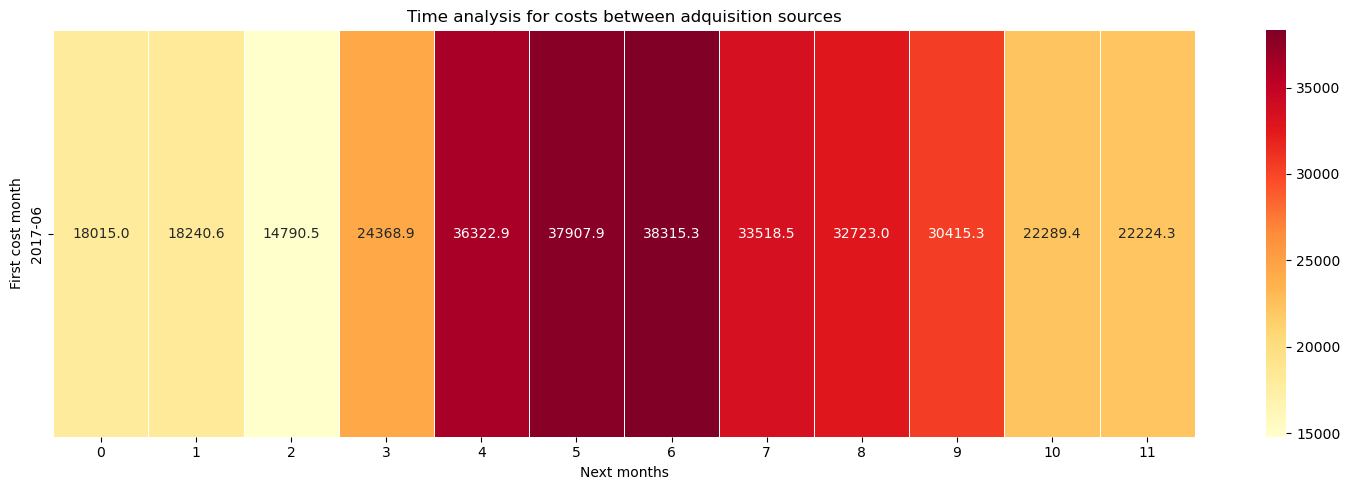

In [34]:
# Determinación de fechas de primer gasto generado por cada fuente de adquisición
first_costs_dates = costs.groupby('source_id')['dt'].min()
first_costs_dates.name = 'first_cost_date'
costs = costs.merge(first_costs_dates.to_frame(), left_on='source_id', right_index=True, how='left')

# Determinación del mes de generación de fechas de gastoy primer gasto
costs['dt_month'] = pd.DatetimeIndex(costs['dt']).to_period('M').to_timestamp()
costs['first_cost_month'] = pd.DatetimeIndex(costs['first_cost_date']).to_period('M').to_timestamp()

# Determinación de ciclos de vida para cohortes
costs['age'] = (costs['dt_month'] - costs['first_cost_month']) / np.timedelta64(30, 'D')
costs['age'] = costs['age'].round().astype('int')


# Generación de cohortes
costs_source_cohorts = costs.groupby(['first_cost_month','age']).agg({'costs':'sum'}).reset_index()

# Generación de tabla pivot
costs_sources_pivot = costs_source_cohorts.pivot_table(
    index='first_cost_month',
    columns='age',
    values='costs'
)

# Generación de heatmap para análisis temporal de costos por fuentes de adquisición
plt.figure(figsize=(15, 5))
sns.heatmap(
    costs_sources_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    yticklabels=[date.strftime('%Y-%m') for date in costs_sources_pivot.index]
        )
plt.title('Time analysis for costs between adquisition sources')
plt.xlabel('Next months')
plt.ylabel('First cost month')
plt.tight_layout()
plt.show()

### 📈 Hallazgos Clave:
1. Gasto Total General
- Inversión total: 329,131.62 durante todo el período analizado
- Promedio por fuente: 47,018.80
- Distribución: Los gastos no están distribuidos uniformemente entre fuentes
2. Análisis por Fuente de Adquisición
Fuentes de Mayor Inversión:
- Fuente 3: 141,321.63 (43% del gasto total) - La más costosa
- Fuente 4: Segundo lugar en gastos
- Fuente 5: Tercer lugar en gastos
Fuentes de Menor Inversión:
- Fuente 9: 5,517.49 - La menos costosa
- Fuentes 6 y 7: Inversiones muy limitadas
3. Análisis Temporal de Gastos
Patrones Identificados:
- Concentración inicial: Los mayores gastos se realizaron en los primeros meses
- Sostenimiento: Algunas fuentes mantuvieron inversión constante a lo largo del tiempo
- Estacionalidad: Se observan picos de gasto en ciertos períodos
4. Eficiencia de la Inversión
Hallazgos Clave:
- Paradoja de inversión: La fuente 3 (mayor gasto) no es la más rentable en términos de LTV
- Mejor ROI: Las fuentes 1 y 2 muestran mejor relación costo-beneficio
- Oportunidades: Fuentes con baja inversión (como la 9) podrían necesitar más presupuesto

### ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

#### Análisis comparativo entre fuentes de adquisición del CAC

=== CAC ANALYSIS BY SOURCE ===
Source number 1.0: CAC = $4.04 (5161.0 customers, $20833.27 spent)
Source number 2.0: CAC = $9.05 (4728.0 customers, $42806.04 spent)
Source number 3.0: CAC = $14.74 (9587.0 customers, $141321.63 spent)
Source number 4.0: CAC = $5.86 (10421.0 customers, $61073.60 spent)
Source number 5.0: CAC = $6.63 (7807.0 customers, $51757.10 spent)
Source number 9.0: CAC = $4.69 (1176.0 customers, $5517.49 spent)
Source number 10.0: CAC = $4.36 (1334.0 customers, $5822.49 spent)

CAC general average: $7.05


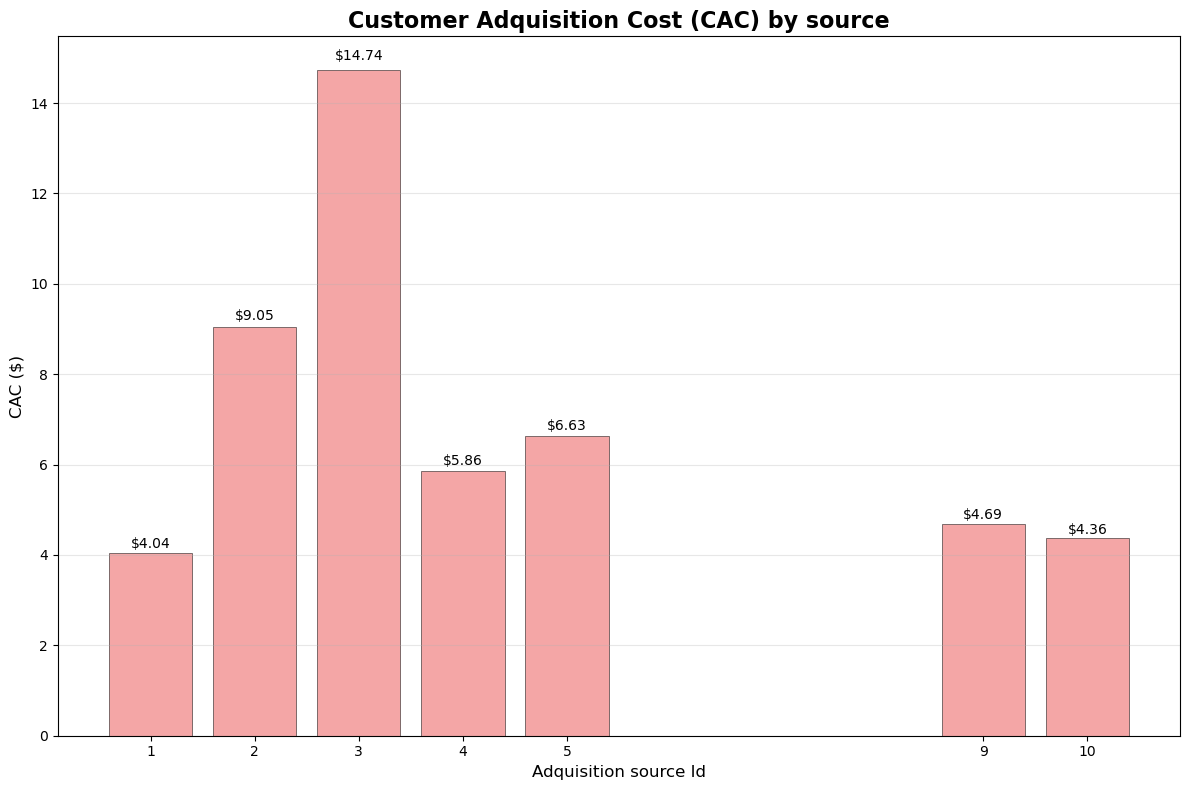

In [35]:
# Obtener número de clientes únicos por fuente de adquisición
customers_per_source = orders_with_source.groupby('Source_Id').agg({'Uid':'nunique'}).reset_index()
customers_per_source.columns = ['source_id', 'unique_customers']

# 3. Combinar costos y clientes para calcular CAC
cac_analysis = source_costs.merge(customers_per_source, on='source_id', how='left')

# 4. Calcular CAC
cac_analysis['CAC'] = cac_analysis['costs'] / cac_analysis['unique_customers']

# 5. Mostrar resultados
print("=== CAC ANALYSIS BY SOURCE ===")
for _, row in cac_analysis.iterrows():
    print(f"Source number {row['source_id']}: CAC = ${row['CAC']:.2f} ({row['unique_customers']} customers, ${row['costs']:.2f} spent)")

print(f"\nCAC general average: ${cac_analysis['CAC'].mean():.2f}")

# 6. Crear gráfico de barras del CAC
plt.figure(figsize=(12, 8))
bars = plt.bar(cac_analysis['source_id'], cac_analysis['CAC'], 
               color='lightcoral', alpha=0.7, edgecolor='black', linewidth=0.5)

plt.title('Customer Adquisition Cost (CAC) by source', fontsize=16, fontweight='bold')
plt.xlabel('Adquisition source Id', fontsize=12)
plt.ylabel('CAC ($)', fontsize=12)
plt.xticks(cac_analysis['source_id'])

# Agregar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:.2f}', ha='center', va='bottom', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 📈 Hallazgos Clave:
1. Panorama General del CAC
- CAC promedio general: 7.05 por cliente adquirido
- Rango de variación: Desde 4.04 hasta 14.74 entre fuentes
- Distribución: Existe una gran disparidad en eficiencia entre fuentes

2. Fuentes de Adquisición Más Eficientes (CAC Bajo)
🏆 Top 3 Fuentes Más Eficientes:
- Fuente 1: CAC = 4.04 (5,161 clientes)
- Fuente 10: CAC = 4.36 (1,334 clientes)
- Fuente 9: CAC = 4.69 (1,176 clientes)
Características:
- Costo 40-45% menor que el promedio general
- Excelente relación costo-beneficio
- Fuente 1 destaca por volumen + eficiencia
  
3. Fuentes de Adquisición Menos Eficientes (CAC Alto)
🔻 Fuentes Menos Eficientes:
- Fuente 3: CAC = 14.74 (9,587 clientes) - La más costosa
- Fuente 2: CAC = 9.05 (4,728 clientes)
- Fuente 5: CAC = 6.63 (7,807 clientes)
Características:
- Fuente 3: CAC 109% superior al promedio
- Paradoja de volumen: Fuente 3 genera más clientes pero a mayor costo

4. Análisis de Eficiencia vs Volumen
Hallazgos Clave:

- Fuente 1: Combina eficiencia + volumen (ideal)
- Fuente 3: Alto volumen pero baja eficiencia (problemática)
- Fuentes 9 y 10: Muy eficientes pero bajo volumen (oportunidad)

### ¿Cuán rentables eran las inversiones? (ROMI)

#### Análisis comparativo entre fuentes de adquisición del ROMI

=== ROMI ANALYSIS BY SOURCE ===
Source number 1.0: ROMI = 113.2% (Profits: $23579.56)
Source number 2.0: ROMI = 43.7% (Profits: $18705.89)
Source number 3.0: ROMI = -70.0% (Profits: $-98878.62)
Source number 4.0: ROMI = -19.6% (Profits: $-11945.02)
Source number 5.0: ROMI = -11.4% (Profits: $-5908.78)
Source number 9.0: ROMI = -15.0% (Profits: $-828.51)
Source number 10.0: ROMI = -30.9% (Profits: $-1800.16)

ROMI general average: 1.4%


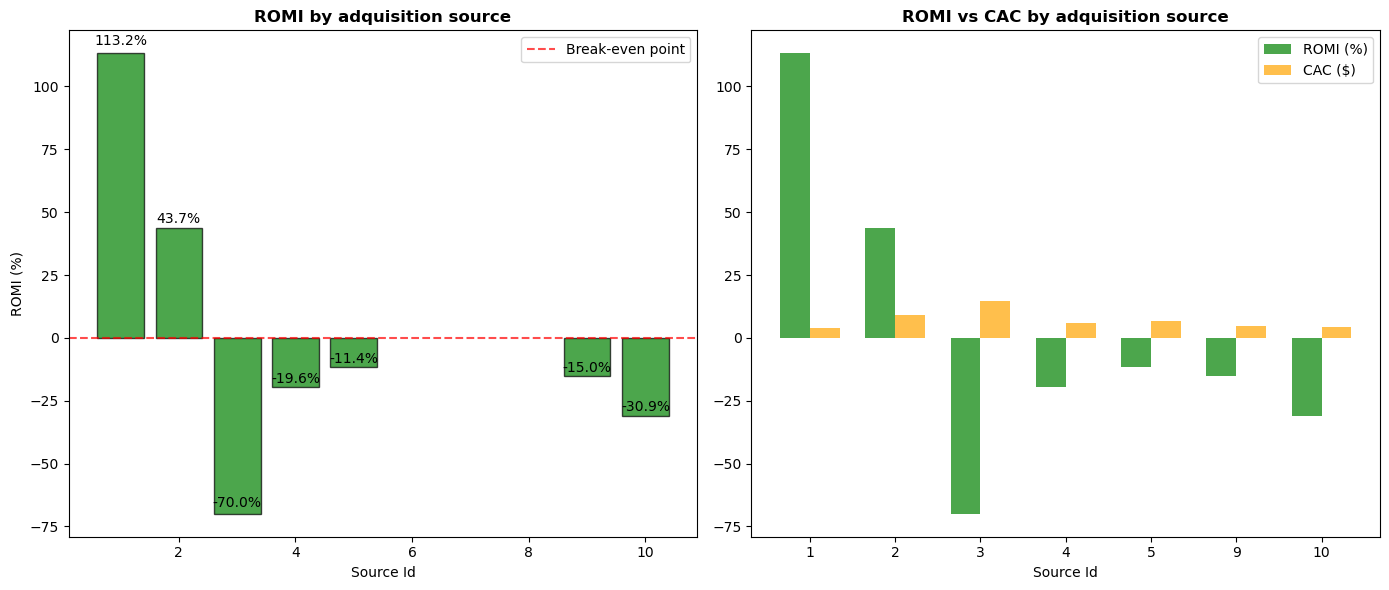


=== EXECUTIVE SUMMARY ROMI ===
Best source: 1.0 (ROMI: 113.2%)
Worst source: 3.0 (ROMI: -70.0%)


In [36]:
# Obtener ingresos totales por fuente de adquisición
revenue_per_source = orders_with_source.groupby('Source_Id').agg({'Revenue':'sum'}).reset_index()
revenue_per_source.columns = ['source_id', 'total_revenue']

# Combinar costos, ingresos y datos de clientes para análisis completo
romi_analysis = source_costs.merge(revenue_per_source, on='source_id', how='left')
romi_analysis = romi_analysis.merge(customers_per_source, on='source_id', how='left')

# Calcular ROMI
romi_analysis['ROMI'] = ((romi_analysis['total_revenue'] - romi_analysis['costs']) / romi_analysis['costs']) * 100

# Calcular métricas adicionales para análisis completo
romi_analysis['profit'] = romi_analysis['total_revenue'] - romi_analysis['costs']

# Mostrar resultados del ROMI
print("=== ROMI ANALYSIS BY SOURCE ===")
for _, row in romi_analysis.iterrows():
    print(f"Source number {row['source_id']}: ROMI = {row['ROMI']:.1f}% (Profits: ${row['profit']:.2f})")

print(f"\nROMI general average: {romi_analysis['ROMI'].mean():.1f}%")

# Crear visualizaciones clave del ROMI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: ROMI por fuente
bars1 = axes[0].bar(romi_analysis['source_id'], romi_analysis['ROMI'], 
                    color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('ROMI by adquisition source', fontweight='bold')
axes[0].set_xlabel('Source Id')
axes[0].set_ylabel('ROMI (%)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even point')
axes[0].legend()

# Agregar valores encima de las barras
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + (abs(height)*0.02),
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Comparación ROMI vs CAC
x_pos = np.arange(len(romi_analysis))
width = 0.35

bars2 = axes[1].bar(x_pos - width/2, romi_analysis['ROMI'], width, 
                    label='ROMI (%)', color='green', alpha=0.7)
bars3 = axes[1].bar(x_pos + width/2, cac_analysis['CAC'], width, 
                    label='CAC ($)', color='orange', alpha=0.7)

axes[1].set_title('ROMI vs CAC by adquisition source', fontweight='bold')
axes[1].set_xlabel('Source Id')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(romi_analysis['source_id'])
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. Resumen ejecutivo del análisis
print("\n=== EXECUTIVE SUMMARY ROMI ===")
best_romi = romi_analysis.loc[romi_analysis['ROMI'].idxmax()]
worst_romi = romi_analysis.loc[romi_analysis['ROMI'].idxmin()]

print(f"Best source: {best_romi['source_id']} (ROMI: {best_romi['ROMI']:.1f}%)")
print(f"Worst source: {worst_romi['source_id']} (ROMI: {worst_romi['ROMI']:.1f}%)")

### 📈 Hallazgos Clave:
1. Panorama General de Rentabilidad
- ROMI promedio general: 1.4%
- Apenas por encima del punto de equilibrio
- Solo 2 de 7 fuentes son rentables (28.6% de éxito)
- La mayoría de las inversiones generaron pérdidas

2. Fuentes Altamente Rentables 🏆
Fuente 1: ROMI = 113.2% 
- La más exitosa con ganancias de 23,579.56
- Por cada dólar invertido, genera 2.13 de retorno
Fuente 2: ROMI = 43.7%
- Rentable con ganancias de 18,705.89
- Por cada dólar invertido, genera 1.44 de retorno

3. Fuentes No Rentables 📉
Fuente 3: ROMI = -70.0% 
- La peor inversión
- Pérdidas masivas de 98,878.62
- A pesar de generar el mayor volumen de clientes (9,587)
Fuentes 4, 5, 9, 10: Todas con ROMI negativo entre -11.4% y -30.9%

# Paso 3. Escribe una conclusión: aconseja a los expertos de marketing cuánto dinero invertir y dónde

🎯 RECOMENDACIONES DE FUENTES/PLATAFORMAS
1. FUENTES ALTAMENTE RECOMENDADAS 🏆

FUENTE 1 - PRIORIDAD MÁXIMA
- Métricas clave: ROMI = 113.2%, CAC = 4.04, LTV = 1.12
- Fundamentación: Combina la mejor rentabilidad con eficiencia en costos
- Recomendación: INCREMENTAR presupuesto en 50-100%

FUENTE 2 - ALTA PRIORIDAD
- Métricas clave: ROMI = 43.7%, CAC = 9.05, LTV = 1.29
- Fundamentación: Rentable y genera el mayor LTV promedio
- Recomendación: INCREMENTAR presupuesto en 30-50%

2. FUENTES A REEVALUAR CRÍTICAMENTE ⚠️

FUENTE 3 - ACCIÓN INMEDIATA REQUERIDA
- Métricas clave: ROMI = -70.0%, CAC = 14.74, Mayor volumen pero pérdidas masivas
- Fundamentación: A pesar de generar 9,587 clientes, produce pérdidas de 98,878
- Recomendación: SUSPENDER temporalmente y optimizar estrategia

3. FUENTES A ELIMINAR O REDUCIR 🔻

FUENTES 4, 5, 9, 10
- Métricas clave: ROMI negativo (-11.4% a -30.9%)
- Fundamentación: Todas generan pérdidas consistentes
- Recomendación: REDUCIR presupuesto en 70% o ELIMINAR

📊 MÉTRICAS EN LAS QUE ME ENFOQUÉ Y POR QUÉ
1. ROMI (Return on Marketing Investment) - MÉTRICA PRINCIPAL

Por qué es clave:
- Mide directamente la rentabilidad de cada peso invertido
- Permite comparar eficiencia entre fuentes
- Identifica qué inversiones generan ganancias vs pérdidas

2. CAC (Customer Acquisition Cost) - MÉTRICA DE EFICIENCIA

Por qué es importante:
- Mide la eficiencia operativa de cada fuente
- Permite optimizar el costo por cliente adquirido
- Fundamental para escalabilidad del negocio

3. LTV (Lifetime Value) - MÉTRICA DE VALOR A LARGO PLAZO

Por qué la incluí:
- Evalúa la calidad de los clientes adquiridos
- Complementa el análisis de rentabilidad
- Indica potencial de crecimiento futuro